# CSCI 567 — Pre-final: Temporally Robust and Fair Credit Risk Prediction
**LendingClub 2007–2018**

- Exp 1: Temporal Robustness — temporal vs random split AUC drop
- Exp 2: Model Design Effects — hyperparameter sweep
- Exp 3: Fairness Analysis — credit history group + income group
- Exp 4: Robustness–Fairness Trade-off
- Exp 5: Neural Network
- Annual AUC trend (2015, 2016, 2017, 2018)

## 0. Setup Environment & Data Load

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!cp "/content/drive/MyDrive/Colab Notebooks/CSCI567/lendingclub/archive.zip" /content/
!unzip -q /content/archive.zip -d /content/

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('/content/accepted_2007_to_2018Q4.csv.gz', low_memory=False)
# df = pd.read_csv(
#     '/content/drive/MyDrive/Colab Notebooks/CSCI567/accepted_2007_to_2018Q4.csv',
#     low_memory=False
# )

print(f'Raw shape: {df.shape}')

Raw shape: (2260701, 151)


In [18]:
!pip install optuna -q

## 1. Preprocessing

In [5]:

# ── Target Creation ──────────────────────────────────────────────────────────
default_labels = ['Charged Off', 'Default',
                  'Does not meet the credit policy. Status:Charged Off']
df['target'] = df['loan_status'].isin(default_labels).astype(int)

# ── Date Parsing ──────────────────────────────────────────────────────────
df['issue_d']  = pd.to_datetime(df['issue_d'],         format='%b-%Y')
df['issue_year'] = df['issue_d'].dt.year
df['age_proxy'] = pd.to_datetime(df['earliest_cr_line'], format='%b-%Y')
df['credit_history_years'] = (df['issue_d'] - df['age_proxy']).dt.days / 365

# ── Feature Selection ──────────────────────────────────────────────────────────
FEATURES = ['loan_amnt', 'int_rate', 'installment', 'annual_inc',
            'dti', 'delinq_2yrs', 'fico_range_low', 'open_acc',
            'pub_rec', 'revol_bal', 'revol_util', 'total_acc',
            'mort_acc', 'pub_rec_bankruptcies']

# ── Sampling (Colab) ──────────────────────────────────────────────
df_sample = df.sample(n=200000, random_state=42).copy()
# df_sample = df.copy()
print(f'Sample shape: {df_sample.shape}')
print(f'Default rate: {df_sample["target"].mean():.3f}')

Sample shape: (200000, 155)
Default rate: 0.119


In [6]:
# Fairness groups will be created after splitting so the cutoffs are learned
# from the temporal training data only.
print('Fairness groups will be built after the split step.')

Fairness groups will be built after the split step.


## 2. Data Splitting

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ── Temporal split: train / val / test ───────────────────────────────────────
train_t = df_sample[df_sample['issue_year'] <= 2013].copy()
val_t   = df_sample[(df_sample['issue_year'] >= 2014) & (df_sample['issue_year'] <= 2015)].copy()
test_t  = df_sample[df_sample['issue_year'] >= 2016].copy()

# ── Random split: train / val / test ─────────────────────────────────────────
rand_train_df, rand_temp_df = train_test_split(
    df_sample, test_size=0.30, random_state=42, stratify=df_sample['target'])

rand_val_df, rand_test_df = train_test_split(
    rand_temp_df, test_size=0.50, random_state=42, stratify=rand_temp_df['target'])

# ── Imputation: learn medians from training splits only ──────────────────────
temporal_fill = train_t[FEATURES + ['credit_history_years']].median()
random_fill   = rand_train_df[FEATURES + ['credit_history_years']].median()

for split_df in [train_t, val_t, test_t]:
    split_df[FEATURES + ['credit_history_years']] = split_df[FEATURES + ['credit_history_years']].fillna(temporal_fill)

for split_df in [rand_train_df, rand_val_df, rand_test_df]:
    split_df[FEATURES + ['credit_history_years']] = split_df[FEATURES + ['credit_history_years']].fillna(random_fill)

# ── Fairness groups: learn cutoffs from temporal train only ──────────────────
credit_bins = pd.qcut(train_t['credit_history_years'], q=3, retbins=True, duplicates='drop')[1]
income_clip_top = train_t['annual_inc'].quantile(0.99)
income_bins = pd.qcut(train_t['annual_inc'].clip(upper=income_clip_top), q=3, retbins=True, duplicates='drop')[1]

credit_bins[0] = -np.inf
credit_bins[-1] = np.inf
income_bins[0] = -np.inf
income_bins[-1] = np.inf

for split_df in [train_t, val_t, test_t, rand_train_df, rand_val_df, rand_test_df]:
    split_df['credit_group'] = pd.cut(split_df['credit_history_years'], bins=credit_bins, labels=['short', 'mid', 'long'], include_lowest=True)
    split_df['income_group'] = pd.cut(split_df['annual_inc'].clip(upper=income_clip_top), bins=income_bins, labels=['low', 'mid', 'high'], include_lowest=True)

X_train_t = train_t[FEATURES]
y_train_t = train_t['target']
X_val_t   = val_t[FEATURES]
y_val_t   = val_t['target']
X_test_t  = test_t[FEATURES]
y_test_t  = test_t['target']

X_rand_tr  = rand_train_df[FEATURES]
y_rand_tr  = rand_train_df['target']
X_rand_val = rand_val_df[FEATURES]
y_rand_val = rand_val_df['target']
X_rand_te  = rand_test_df[FEATURES]
y_rand_te  = rand_test_df['target']

# ── Scaling: fit each scaler on its own training split only ──────────────────
scaler_t = StandardScaler()
X_train_t_sc = scaler_t.fit_transform(X_train_t)
X_val_t_sc   = scaler_t.transform(X_val_t)
X_test_t_sc  = scaler_t.transform(X_test_t)

scaler_r = StandardScaler()
X_rand_tr_sc  = scaler_r.fit_transform(X_rand_tr)
X_rand_val_sc = scaler_r.transform(X_rand_val)
X_rand_te_sc  = scaler_r.transform(X_rand_te)

print('Temporal split')
print(f'  Train (<=2013):   {len(X_train_t):,}')
print(f'  Val (2014-2015):  {len(X_val_t):,}')
print(f'  Test (>=2016):    {len(X_test_t):,}')

print('\nRandom split')
print(f'  Train: {len(X_rand_tr):,}')
print(f'  Val:   {len(X_rand_val):,}')
print(f'  Test:  {len(X_rand_te):,}')

print('\nTemporal-train fairness group distribution')
print(train_t['credit_group'].value_counts())
print(train_t['income_group'].value_counts())

Temporal split
  Train (<=2013):   20,286
  Val (2014-2015):  58,114
  Test (>=2016):    121,596

Random split
  Train: 140,000
  Val:   30,000
  Test:  30,000

Temporal-train fairness group distribution
credit_group
mid      6775
short    6764
long     6747
Name: count, dtype: int64
income_group
low     7220
high    6728
mid     6338
Name: count, dtype: int64


In [8]:
# ── By year temporal test sets (AUC over time) ──────────────────────────────
yearly_tests = {}
for yr in [2016, 2017, 2018]:
    sub = df_sample[df_sample['issue_year'] == yr].copy()
    if len(sub) > 0:
        sub[FEATURES + ['credit_history_years']] = sub[FEATURES + ['credit_history_years']].fillna(temporal_fill)
        sub['credit_group'] = pd.cut(sub['credit_history_years'], bins=credit_bins, labels=['short', 'mid', 'long'], include_lowest=True)
        sub['income_group'] = pd.cut(sub['annual_inc'].clip(upper=income_clip_top), bins=income_bins, labels=['low', 'mid', 'high'], include_lowest=True)
        yearly_tests[yr] = (sub[FEATURES], sub['target'], scaler_t.transform(sub[FEATURES]), sub)
        print(f'{yr}: {len(sub):,} samples, default rate={sub["target"].mean():.3f}')

2016: 38,347 samples, default rate=0.156
2017: 39,269 samples, default rate=0.090
2018: 43,980 samples, default rate=0.017


## 3. Model Definition — Full Model + Hyperparameter Sweep


In [66]:
# Reusable evaluation helpers for any model family
from sklearn.base import clone
from sklearn.metrics import roc_auc_score, accuracy_score, brier_score_loss
from sklearn.metrics import recall_score, f1_score, precision_score
import time

def evaluate_model_configs(model_configs):
    eval_results = {}
    for name, (model, input_type) in model_configs.items():
        t0 = time.time()
        temporal_model = clone(model)
        random_model   = clone(model)

        if input_type == 'scaled':
            Xtr_t, Xva_t, Xte_t = X_train_t_sc, X_val_t_sc, X_test_t_sc
            Xtr_r, Xva_r, Xte_r = X_rand_tr_sc, X_rand_val_sc, X_rand_te_sc
        else:
            Xtr_t, Xva_t, Xte_t = X_train_t, X_val_t, X_test_t
            Xtr_r, Xva_r, Xte_r = X_rand_tr, X_rand_val, X_rand_te

        temporal_model.fit(Xtr_t, y_train_t)
        random_model.fit(Xtr_r, y_rand_tr)

        y_prob_t_val = temporal_model.predict_proba(Xva_t)[:, 1]
        y_pred_t_val = temporal_model.predict(Xva_t)
        y_prob_t = temporal_model.predict_proba(Xte_t)[:, 1]
        y_pred_t = temporal_model.predict(Xte_t)

        y_prob_r_val = random_model.predict_proba(Xva_r)[:, 1]
        y_pred_r_val = random_model.predict(Xva_r)
        y_prob_r = random_model.predict_proba(Xte_r)[:, 1]
        y_pred_r = random_model.predict(Xte_r)

        eval_results[name] = {
            'temporal': {
                'val_y_prob': y_prob_t_val,
                'val_y_pred': y_pred_t_val,
                'val_auc': roc_auc_score(y_val_t, y_prob_t_val),
                'val_acc': accuracy_score(y_val_t, y_pred_t_val),
                'val_brier': brier_score_loss(y_val_t, y_prob_t_val),
                'val_recall': recall_score(y_val_t, y_pred_t_val, zero_division=0),
                'val_precision': precision_score(y_val_t, y_pred_t_val, zero_division=0),
                'val_f1': f1_score(y_val_t, y_pred_t_val, zero_division=0),
                'y_pred': y_pred_t,
                'y_prob': y_prob_t,
                'auc': roc_auc_score(y_test_t, y_prob_t),
                'acc': accuracy_score(y_test_t, y_pred_t),
                'brier': brier_score_loss(y_test_t, y_prob_t),
                'recall': recall_score(y_test_t, y_pred_t, zero_division=0),
                'precision': precision_score(y_test_t, y_pred_t, zero_division=0),
                'f1': f1_score(y_test_t, y_pred_t, zero_division=0),
                'model': temporal_model,
            },
            'random': {
                'val_y_prob': y_prob_r_val,
                'val_y_pred': y_pred_r_val,
                'val_auc': roc_auc_score(y_rand_val, y_prob_r_val),
                'val_acc': accuracy_score(y_rand_val, y_pred_r_val),
                'val_brier': brier_score_loss(y_rand_val, y_prob_r_val),
                'val_recall': recall_score(y_rand_val, y_pred_r_val, zero_division=0),
                'val_precision': precision_score(y_rand_val, y_pred_r_val, zero_division=0),
                'val_f1': f1_score(y_rand_val, y_pred_r_val, zero_division=0),
                'y_prob': y_prob_r,
                'y_pred': y_pred_r,
                'auc': roc_auc_score(y_rand_te, y_prob_r),
                'acc': accuracy_score(y_rand_te, y_pred_r),
                'brier': brier_score_loss(y_rand_te, y_prob_r),
                'recall': recall_score(y_rand_te, y_pred_r, zero_division=0),
                'precision': precision_score(y_rand_te, y_pred_r, zero_division=0),
                'f1': f1_score(y_rand_te, y_pred_r, zero_division=0),
                'model': random_model,
            },
            'yearly': {}
        }

        for yr, (X_yr, y_yr, X_yr_sc, _) in yearly_tests.items():
            X_in = X_yr_sc if input_type == 'scaled' else X_yr
            yp = temporal_model.predict_proba(X_in)[:, 1]
            eval_results[name]['yearly'][yr] = roc_auc_score(y_yr, yp)

        eval_results[name]['auc_drop'] = eval_results[name]['random']['auc'] - eval_results[name]['temporal']['auc']
        eval_results[name]['val_auc_drop'] = eval_results[name]['random']['val_auc'] - eval_results[name]['temporal']['val_auc']
    return eval_results


In [64]:
def print_selection_table(eval_results, sort_key='val_auc', reverse=True, title=None, mode='val'):
    if title:
        print(f'\n=== {title} ===')

    if mode == 'val':
        key_fn = {
            'val_auc': lambda x: x[1]['temporal']['val_auc'],
            'val_auc_drop': lambda x: x[1]['val_auc_drop'],
            'val_recall': lambda x: x[1]['temporal']['val_recall'],
            'val_precision': lambda x: x[1]['temporal']['val_precision'],
            'val_f1': lambda x: x[1]['temporal']['val_f1'],
        }.get(sort_key, lambda x: x[1]['temporal']['val_auc'])

        for name, res in sorted(eval_results.items(), key=key_fn, reverse=reverse):
            print(f"{name:20s}  "
                  f"temp_val_AUC={res['temporal']['val_auc']:.4f}  "
                  f"rand_val_AUC={res['random']['val_auc']:.4f}  "
                  f"val_AUC_drop={res['val_auc_drop']:.4f}  "
                  f"val_Recall={res['temporal']['val_recall']:.4f}  "
                  f"val_Precision={res['temporal']['val_precision']:.4f}  "
                  f"val_F1={res['temporal']['val_f1']:.4f}")

    elif mode == 'test':
        key_fn = {
            'test_auc': lambda x: x[1]['temporal']['auc'],
            'test_auc_drop': lambda x: x[1]['auc_drop'],
            'recall': lambda x: x[1]['temporal']['recall'],
            'precision': lambda x: x[1]['temporal']['precision'],
            'f1': lambda x: x[1]['temporal']['f1'],
        }.get(sort_key, lambda x: x[1]['temporal']['auc'])

        for name, res in sorted(eval_results.items(), key=key_fn, reverse=reverse):
            print(f"{name:20s}  "
                  f"temp_test_AUC={res['temporal']['auc']:.4f}  "
                  f"random_test_AUC={res['random']['auc']:.4f}  "
                  f"test_AUC_drop={res['auc_drop']:.4f}  "
                  f"Recall={res['temporal']['recall']:.4f}  "
                  f"Precision={res['temporal']['precision']:.4f}  "
                  f"F1={res['temporal']['f1']:.4f}")

In [63]:
def print_best_summary(eval_results, prefix=None, title=None):
    # prefix filtering (ex: 'XGB_', 'LR_', 'RF_')
    filtered = {k: v for k, v in eval_results.items()
                if (k.startswith(prefix) if prefix else True)}

    best_val      = max(filtered.items(), key=lambda x: x[1]['temporal']['val_auc'])
    best_robust   = min(filtered.items(), key=lambda x: x[1]['auc_drop'])
    best_balanced = max(filtered.items(), key=lambda x: x[1]['temporal']['val_auc'] - x[1]['auc_drop'])

    if title:
        print(f'=== {title} ===')

    print(f"Best by temporal val AUC: {best_val[0]}")
    print(f"  val_AUC={best_val[1]['temporal']['val_auc']:.4f}  test_AUC={best_val[1]['temporal']['auc']:.4f}  AUC_drop={best_val[1]['auc_drop']:.4f}")
    print()
    print(f"Best by robustness (smallest AUC drop): {best_robust[0]}")
    print(f"  val_AUC={best_robust[1]['temporal']['val_auc']:.4f}  test_AUC={best_robust[1]['temporal']['auc']:.4f}  AUC_drop={best_robust[1]['auc_drop']:.4f}")
    print()
    print(f"Best balanced (val_AUC - AUC_drop): {best_balanced[0]}")
    print(f"  val_AUC={best_balanced[1]['temporal']['val_auc']:.4f}  test_AUC={best_balanced[1]['temporal']['auc']:.4f}  AUC_drop={best_balanced[1]['auc_drop']:.4f}")

In [12]:
def print_optuna_results(study, top_trials, title='Optuna Results'):
    print(f'\n=== {title} ===')
    print(f'Best score: {study.best_value:.4f}')
    print(f'\nBest params:')
    for k, v in study.best_params.items():
        print(f'  {k:20s}: {v}')

    print(f'\n=== Top {len(top_trials)} Trials ===')
    for i, t in enumerate(top_trials):
        print(f'\n[{i+1}] score={t.value:.4f}')
        for k, v in t.params.items():
            print(f'  {k:20s}: {v}')

In [71]:
import optuna
from optuna.samplers import TPESampler

w_robustness  = 0.35
w_performance = 0.15
w_recall      = 0.50

## 3.1 XGBoost Test Code (Find Best)


In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

# ── All Model Definitions ─────────────────────────────────────────────────────
# LR: C Value sweep (regularization strength)
# Tree: max_depth sweep
# RF: n_estimators x max_depth
# XGB: learning_rate x max_depth
# NN: hidden layer size x alpha (L2)

XGB_MODEL_CONFIGS = {
    # Baseline
    'XGB_base':         (XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=4, eval_metric='logloss', random_state=42), 'raw'),

    # learning_rate sweep
    'XGB_lr0.005':       (XGBClassifier(n_estimators=100, learning_rate=0.005, max_depth=4, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_lr0.01':       (XGBClassifier(n_estimators=100, learning_rate=0.01, max_depth=4, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_lr0.05':       (XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=4, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_lr0.3':        (XGBClassifier(n_estimators=100, learning_rate=0.3,  max_depth=4, eval_metric='logloss', random_state=42), 'raw'),

    # max_depth sweep
    'XGB_d3_lr0.01':           (XGBClassifier(n_estimators=100, learning_rate=0.01, max_depth=3, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_d6_lr0.01':           (XGBClassifier(n_estimators=100, learning_rate=0.01, max_depth=6, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_d8_lr0.01':           (XGBClassifier(n_estimators=100, learning_rate=0.01, max_depth=8, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_d3_lr0.03':           (XGBClassifier(n_estimators=100, learning_rate=0.03, max_depth=3, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_d6_lr0.03':           (XGBClassifier(n_estimators=100, learning_rate=0.03, max_depth=6, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_d8_lr0.03':           (XGBClassifier(n_estimators=100, learning_rate=0.03, max_depth=8, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_d3_lr0.05':           (XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_d6_lr0.05':           (XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=6, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_d8_lr0.05':           (XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=8, eval_metric='logloss', random_state=42), 'raw'),

    # min_child_weight sweep
    'XGB_mcw3_lr0.01':         (XGBClassifier(n_estimators=100, learning_rate=0.01, max_depth=3, min_child_weight=3,  eval_metric='logloss', random_state=42), 'raw'),
    'XGB_mcw5_lr0.01':         (XGBClassifier(n_estimators=100, learning_rate=0.01, max_depth=3, min_child_weight=5,  eval_metric='logloss', random_state=42), 'raw'),
    'XGB_mcw10_lr0.01':        (XGBClassifier(n_estimators=100, learning_rate=0.01, max_depth=3, min_child_weight=10, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_mcw3_lr0.03':         (XGBClassifier(n_estimators=100, learning_rate=0.03, max_depth=3, min_child_weight=3,  eval_metric='logloss', random_state=42), 'raw'),
    'XGB_mcw5_lr0.03':         (XGBClassifier(n_estimators=100, learning_rate=0.03, max_depth=3, min_child_weight=5,  eval_metric='logloss', random_state=42), 'raw'),
    'XGB_mcw10_lr0.03':        (XGBClassifier(n_estimators=100, learning_rate=0.03, max_depth=3, min_child_weight=10, eval_metric='logloss', random_state=42), 'raw'),

    # subsample sweep
    'XGB_sub0.6_lr0.01':       (XGBClassifier(n_estimators=100, learning_rate=0.01, max_depth=3, min_child_weight=3, subsample=0.6, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_sub0.7_lr0.01':       (XGBClassifier(n_estimators=100, learning_rate=0.01, max_depth=3, min_child_weight=3, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_sub0.8_lr0.01':       (XGBClassifier(n_estimators=100, learning_rate=0.01, max_depth=3, min_child_weight=3, subsample=0.8, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_sub0.6_lr0.03':       (XGBClassifier(n_estimators=100, learning_rate=0.03, max_depth=3, min_child_weight=3, subsample=0.6, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_sub0.7_lr0.03':       (XGBClassifier(n_estimators=100, learning_rate=0.03, max_depth=3, min_child_weight=3, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_sub0.8_lr0.03':       (XGBClassifier(n_estimators=100, learning_rate=0.03, max_depth=3, min_child_weight=3, subsample=0.8, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_sub0.6_lr0.05':       (XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, min_child_weight=3, subsample=0.6, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_sub0.7_lr0.05':       (XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, min_child_weight=3, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_sub0.8_lr0.05':       (XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, min_child_weight=3, subsample=0.8, eval_metric='logloss', random_state=42), 'raw'),

    # colsample_bytree sweep
    'XGB_col0.6_lr0.01':       (XGBClassifier(n_estimators=100, learning_rate=0.01, max_depth=3, min_child_weight=3, subsample=0.7, colsample_bytree=0.6, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_col0.7_lr0.01':       (XGBClassifier(n_estimators=100, learning_rate=0.01, max_depth=3, min_child_weight=3, subsample=0.7, colsample_bytree=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_col0.8_lr0.01':       (XGBClassifier(n_estimators=100, learning_rate=0.01, max_depth=3, min_child_weight=3, subsample=0.7, colsample_bytree=0.8, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_col0.6_lr0.03':       (XGBClassifier(n_estimators=100, learning_rate=0.03, max_depth=3, min_child_weight=3, subsample=0.7, colsample_bytree=0.6, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_col0.7_lr0.03':       (XGBClassifier(n_estimators=100, learning_rate=0.03, max_depth=3, min_child_weight=3, subsample=0.7, colsample_bytree=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_col0.8_lr0.03':       (XGBClassifier(n_estimators=100, learning_rate=0.03, max_depth=3, min_child_weight=3, subsample=0.7, colsample_bytree=0.8, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_col0.6_lr0.05':       (XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, min_child_weight=3, subsample=0.7, colsample_bytree=0.6, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_col0.7_lr0.05':       (XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, min_child_weight=3, subsample=0.7, colsample_bytree=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_col0.8_lr0.05':       (XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, min_child_weight=3, subsample=0.7, colsample_bytree=0.8, eval_metric='logloss', random_state=42), 'raw'),

    # colsample_bytree sweep
    'XGB_col0.6_lr0.01_rmsub':       (XGBClassifier(n_estimators=100, learning_rate=0.01, max_depth=3, min_child_weight=3, colsample_bytree=0.6, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_col0.7_lr0.01_rmsub':       (XGBClassifier(n_estimators=100, learning_rate=0.01, max_depth=3, min_child_weight=3, colsample_bytree=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_col0.8_lr0.01_rmsub':       (XGBClassifier(n_estimators=100, learning_rate=0.01, max_depth=3, min_child_weight=3, colsample_bytree=0.8, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_col0.6_lr0.03_rmsub':       (XGBClassifier(n_estimators=100, learning_rate=0.03, max_depth=3, min_child_weight=3, colsample_bytree=0.6, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_col0.7_lr0.03_rmsub':       (XGBClassifier(n_estimators=100, learning_rate=0.03, max_depth=3, min_child_weight=3, colsample_bytree=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_col0.8_lr0.03_rmsub':       (XGBClassifier(n_estimators=100, learning_rate=0.03, max_depth=3, min_child_weight=3, colsample_bytree=0.8, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_col0.6_lr0.05_rmsub':       (XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, min_child_weight=3, colsample_bytree=0.6, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_col0.7_lr0.05_rmsub':       (XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, min_child_weight=3, colsample_bytree=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_col0.8_lr0.05_rmsub':       (XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, min_child_weight=3, colsample_bytree=0.8, eval_metric='logloss', random_state=42), 'raw'),

    # colsample_bytree sweep
    'XGB_col0.6_lr0.01_rmmcw':       (XGBClassifier(n_estimators=100, learning_rate=0.01, max_depth=3, subsample=0.7, colsample_bytree=0.6, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_col0.7_lr0.01_rmmcw':       (XGBClassifier(n_estimators=100, learning_rate=0.01, max_depth=3, subsample=0.7, colsample_bytree=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_col0.8_lr0.01_rmmcw':       (XGBClassifier(n_estimators=100, learning_rate=0.01, max_depth=3, subsample=0.7, colsample_bytree=0.8, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_col0.6_lr0.03_rmmcw':       (XGBClassifier(n_estimators=100, learning_rate=0.03, max_depth=3, subsample=0.7, colsample_bytree=0.6, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_col0.7_lr0.03_rmmcw':       (XGBClassifier(n_estimators=100, learning_rate=0.03, max_depth=3, subsample=0.7, colsample_bytree=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_col0.8_lr0.03_rmmcw':       (XGBClassifier(n_estimators=100, learning_rate=0.03, max_depth=3, subsample=0.7, colsample_bytree=0.8, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_col0.6_lr0.05_rmmcw':       (XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, subsample=0.7, colsample_bytree=0.6, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_col0.7_lr0.05_rmmcw':       (XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, subsample=0.7, colsample_bytree=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_col0.8_lr0.05_rmmcw':       (XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, subsample=0.7, colsample_bytree=0.8, eval_metric='logloss', random_state=42), 'raw'),

    # subsample sweep
    'XGB_gamma1_lr0.01':       (XGBClassifier(n_estimators=100, learning_rate=0.01, max_depth=3, min_child_weight=3, gamma=1, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_gamma3_lr0.01':       (XGBClassifier(n_estimators=100, learning_rate=0.01, max_depth=3, min_child_weight=3, gamma=3, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_gamma5_lr0.01':       (XGBClassifier(n_estimators=100, learning_rate=0.01, max_depth=3, min_child_weight=3, gamma=5, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_gamma1_lr0.03':       (XGBClassifier(n_estimators=100, learning_rate=0.03, max_depth=3, min_child_weight=3, gamma=1, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_gamma3_lr0.03':       (XGBClassifier(n_estimators=100, learning_rate=0.03, max_depth=3, min_child_weight=3, gamma=3, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_gamma5_lr0.03':       (XGBClassifier(n_estimators=100, learning_rate=0.03, max_depth=3, min_child_weight=3, gamma=5, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_gamma1_lr0.05':       (XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, min_child_weight=3, gamma=1, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_gamma3_lr0.05':       (XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, min_child_weight=3, gamma=3, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_gamma5_lr0.05':       (XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, min_child_weight=3, gamma=5, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),

    # L1 (reg_alpha) + gamma + lr 조합
    'XGB_L1_1_g1_lr0.01':  (XGBClassifier(n_estimators=100, learning_rate=0.01, max_depth=3, min_child_weight=3, gamma=1, reg_alpha=1.0,  subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L1_5_g1_lr0.01':  (XGBClassifier(n_estimators=100, learning_rate=0.01, max_depth=3, min_child_weight=3, gamma=1, reg_alpha=5.0,  subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L1_10_g1_lr0.01': (XGBClassifier(n_estimators=100, learning_rate=0.01, max_depth=3, min_child_weight=3, gamma=1, reg_alpha=10.0, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L1_1_g3_lr0.01':  (XGBClassifier(n_estimators=100, learning_rate=0.01, max_depth=3, min_child_weight=3, gamma=3, reg_alpha=1.0,  subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L1_5_g3_lr0.01':  (XGBClassifier(n_estimators=100, learning_rate=0.01, max_depth=3, min_child_weight=3, gamma=3, reg_alpha=5.0,  subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L1_10_g3_lr0.01': (XGBClassifier(n_estimators=100, learning_rate=0.01, max_depth=3, min_child_weight=3, gamma=3, reg_alpha=10.0, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L1_1_g5_lr0.01':  (XGBClassifier(n_estimators=100, learning_rate=0.01, max_depth=3, min_child_weight=3, gamma=5, reg_alpha=1.0,  subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L1_5_g5_lr0.01':  (XGBClassifier(n_estimators=100, learning_rate=0.01, max_depth=3, min_child_weight=3, gamma=5, reg_alpha=5.0,  subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L1_10_g5_lr0.01': (XGBClassifier(n_estimators=100, learning_rate=0.01, max_depth=3, min_child_weight=3, gamma=5, reg_alpha=10.0, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),

    'XGB_L1_1_g1_lr0.03':  (XGBClassifier(n_estimators=100, learning_rate=0.03, max_depth=3, min_child_weight=3, gamma=1, reg_alpha=1.0,  subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L1_5_g1_lr0.03':  (XGBClassifier(n_estimators=100, learning_rate=0.03, max_depth=3, min_child_weight=3, gamma=1, reg_alpha=5.0,  subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L1_10_g1_lr0.03': (XGBClassifier(n_estimators=100, learning_rate=0.03, max_depth=3, min_child_weight=3, gamma=1, reg_alpha=10.0, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L1_1_g3_lr0.03':  (XGBClassifier(n_estimators=100, learning_rate=0.03, max_depth=3, min_child_weight=3, gamma=3, reg_alpha=1.0,  subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L1_5_g3_lr0.03':  (XGBClassifier(n_estimators=100, learning_rate=0.03, max_depth=3, min_child_weight=3, gamma=3, reg_alpha=5.0,  subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L1_10_g3_lr0.03': (XGBClassifier(n_estimators=100, learning_rate=0.03, max_depth=3, min_child_weight=3, gamma=3, reg_alpha=10.0, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L1_1_g5_lr0.03':  (XGBClassifier(n_estimators=100, learning_rate=0.03, max_depth=3, min_child_weight=3, gamma=5, reg_alpha=1.0,  subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L1_5_g5_lr0.03':  (XGBClassifier(n_estimators=100, learning_rate=0.03, max_depth=3, min_child_weight=3, gamma=5, reg_alpha=5.0,  subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L1_10_g5_lr0.03': (XGBClassifier(n_estimators=100, learning_rate=0.03, max_depth=3, min_child_weight=3, gamma=5, reg_alpha=10.0, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),

    'XGB_L1_1_g1_lr0.05':  (XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, min_child_weight=3, gamma=1, reg_alpha=1.0,  subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L1_5_g1_lr0.05':  (XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, min_child_weight=3, gamma=1, reg_alpha=5.0,  subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L1_10_g1_lr0.05': (XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, min_child_weight=3, gamma=1, reg_alpha=10.0, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L1_1_g3_lr0.05':  (XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, min_child_weight=3, gamma=3, reg_alpha=1.0,  subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L1_5_g3_lr0.05':  (XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, min_child_weight=3, gamma=3, reg_alpha=5.0,  subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L1_10_g3_lr0.05': (XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, min_child_weight=3, gamma=3, reg_alpha=10.0, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L1_1_g5_lr0.05':  (XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, min_child_weight=3, gamma=5, reg_alpha=1.0,  subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L1_5_g5_lr0.05':  (XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, min_child_weight=3, gamma=5, reg_alpha=5.0,  subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L1_10_g5_lr0.05': (XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, min_child_weight=3, gamma=5, reg_alpha=10.0, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),

    # L2 (reg_lambda) + gamma + lr (27)
    # 'XGB_L2_1_g1_lr0.01':  (XGBClassifier(n_estimators=100, learning_rate=0.01, max_depth=3, min_child_weight=3, gamma=1, reg_lambda=1.0,  subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    # 'XGB_L2_5_g1_lr0.01':  (XGBClassifier(n_estimators=100, learning_rate=0.01, max_depth=3, min_child_weight=3, gamma=1, reg_lambda=5.0,  subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    # 'XGB_L2_10_g1_lr0.01': (XGBClassifier(n_estimators=100, learning_rate=0.01, max_depth=3, min_child_weight=3, gamma=1, reg_lambda=10.0, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    # 'XGB_L2_1_g3_lr0.01':  (XGBClassifier(n_estimators=100, learning_rate=0.01, max_depth=3, min_child_weight=3, gamma=3, reg_lambda=1.0,  subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    # 'XGB_L2_5_g3_lr0.01':  (XGBClassifier(n_estimators=100, learning_rate=0.01, max_depth=3, min_child_weight=3, gamma=3, reg_lambda=5.0,  subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    # 'XGB_L2_10_g3_lr0.01': (XGBClassifier(n_estimators=100, learning_rate=0.01, max_depth=3, min_child_weight=3, gamma=3, reg_lambda=10.0, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    # 'XGB_L2_1_g5_lr0.01':  (XGBClassifier(n_estimators=100, learning_rate=0.01, max_depth=3, min_child_weight=3, gamma=5, reg_lambda=1.0,  subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    # 'XGB_L2_5_g5_lr0.01':  (XGBClassifier(n_estimators=100, learning_rate=0.01, max_depth=3, min_child_weight=3, gamma=5, reg_lambda=5.0,  subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    # 'XGB_L2_10_g5_lr0.01': (XGBClassifier(n_estimators=100, learning_rate=0.01, max_depth=3, min_child_weight=3, gamma=5, reg_lambda=10.0, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),

    # 'XGB_L2_1_g1_lr0.03':  (XGBClassifier(n_estimators=100, learning_rate=0.03, max_depth=3, min_child_weight=3, gamma=1, reg_lambda=1.0,  subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    # 'XGB_L2_5_g1_lr0.03':  (XGBClassifier(n_estimators=100, learning_rate=0.03, max_depth=3, min_child_weight=3, gamma=1, reg_lambda=5.0,  subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    # 'XGB_L2_10_g1_lr0.03': (XGBClassifier(n_estimators=100, learning_rate=0.03, max_depth=3, min_child_weight=3, gamma=1, reg_lambda=10.0, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    # 'XGB_L2_1_g3_lr0.03':  (XGBClassifier(n_estimators=100, learning_rate=0.03, max_depth=3, min_child_weight=3, gamma=3, reg_lambda=1.0,  subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    # 'XGB_L2_5_g3_lr0.03':  (XGBClassifier(n_estimators=100, learning_rate=0.03, max_depth=3, min_child_weight=3, gamma=3, reg_lambda=5.0,  subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    # 'XGB_L2_10_g3_lr0.03': (XGBClassifier(n_estimators=100, learning_rate=0.03, max_depth=3, min_child_weight=3, gamma=3, reg_lambda=10.0, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    # 'XGB_L2_1_g5_lr0.03':  (XGBClassifier(n_estimators=100, learning_rate=0.03, max_depth=3, min_child_weight=3, gamma=5, reg_lambda=1.0,  subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    # 'XGB_L2_5_g5_lr0.03':  (XGBClassifier(n_estimators=100, learning_rate=0.03, max_depth=3, min_child_weight=3, gamma=5, reg_lambda=5.0,  subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    # 'XGB_L2_10_g5_lr0.03': (XGBClassifier(n_estimators=100, learning_rate=0.03, max_depth=3, min_child_weight=3, gamma=5, reg_lambda=10.0, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),

    # 'XGB_L2_1_g1_lr0.05':  (XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, min_child_weight=3, gamma=1, reg_lambda=1.0,  subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    # 'XGB_L2_5_g1_lr0.05':  (XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, min_child_weight=3, gamma=1, reg_lambda=5.0,  subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    # 'XGB_L2_10_g1_lr0.05': (XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, min_child_weight=3, gamma=1, reg_lambda=10.0, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    # 'XGB_L2_1_g3_lr0.05':  (XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, min_child_weight=3, gamma=3, reg_lambda=1.0,  subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    # 'XGB_L2_5_g3_lr0.05':  (XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, min_child_weight=3, gamma=3, reg_lambda=5.0,  subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    # 'XGB_L2_10_g3_lr0.05': (XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, min_child_weight=3, gamma=3, reg_lambda=10.0, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    # 'XGB_L2_1_g5_lr0.05':  (XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, min_child_weight=3, gamma=5, reg_lambda=1.0,  subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    # 'XGB_L2_5_g5_lr0.05':  (XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, min_child_weight=3, gamma=5, reg_lambda=5.0,  subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    # 'XGB_L2_10_g5_lr0.05': (XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, min_child_weight=3, gamma=5, reg_lambda=10.0, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),

    'XGB_L2(1)_g1_lr0.01_n50':   (XGBClassifier(n_estimators=50,  learning_rate=0.01, max_depth=3, min_child_weight=3, gamma=1, reg_lambda=1.0, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L2(1)_g1_lr0.01_n75':   (XGBClassifier(n_estimators=75,  learning_rate=0.01, max_depth=3, min_child_weight=3, gamma=1, reg_lambda=1.0, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L2(1)_g1_lr0.01_n100':  (XGBClassifier(n_estimators=100, learning_rate=0.01, max_depth=3, min_child_weight=3, gamma=1, reg_lambda=1.0, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L2(1)_g1_lr0.03_n50':   (XGBClassifier(n_estimators=50,  learning_rate=0.03, max_depth=3, min_child_weight=3, gamma=1, reg_lambda=1.0, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L2(1)_g1_lr0.03_n75':   (XGBClassifier(n_estimators=75,  learning_rate=0.03, max_depth=3, min_child_weight=3, gamma=1, reg_lambda=1.0, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L2(1)_g1_lr0.03_n100':  (XGBClassifier(n_estimators=100, learning_rate=0.03, max_depth=3, min_child_weight=3, gamma=1, reg_lambda=1.0, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L2(1)_g1_lr0.05_n50':   (XGBClassifier(n_estimators=50,  learning_rate=0.05, max_depth=3, min_child_weight=3, gamma=1, reg_lambda=1.0, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L2(1)_g1_lr0.05_n75':   (XGBClassifier(n_estimators=75,  learning_rate=0.05, max_depth=3, min_child_weight=3, gamma=1, reg_lambda=1.0, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L2(1)_g1_lr0.05_n100':  (XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, min_child_weight=3, gamma=1, reg_lambda=1.0, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L2(1)_g3_lr0.01_n50':   (XGBClassifier(n_estimators=50,  learning_rate=0.01, max_depth=3, min_child_weight=3, gamma=3, reg_lambda=1.0, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L2(1)_g3_lr0.01_n75':   (XGBClassifier(n_estimators=75,  learning_rate=0.01, max_depth=3, min_child_weight=3, gamma=3, reg_lambda=1.0, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L2(1)_g3_lr0.01_n100':  (XGBClassifier(n_estimators=100, learning_rate=0.01, max_depth=3, min_child_weight=3, gamma=3, reg_lambda=1.0, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L2(1)_g3_lr0.03_n50':   (XGBClassifier(n_estimators=50,  learning_rate=0.03, max_depth=3, min_child_weight=3, gamma=3, reg_lambda=1.0, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L2(1)_g3_lr0.03_n75':   (XGBClassifier(n_estimators=75,  learning_rate=0.03, max_depth=3, min_child_weight=3, gamma=3, reg_lambda=1.0, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L2(1)_g3_lr0.03_n100':  (XGBClassifier(n_estimators=100, learning_rate=0.03, max_depth=3, min_child_weight=3, gamma=3, reg_lambda=1.0, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L2(1)_g3_lr0.05_n50':   (XGBClassifier(n_estimators=50,  learning_rate=0.05, max_depth=3, min_child_weight=3, gamma=3, reg_lambda=1.0, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L2(1)_g3_lr0.05_n75':   (XGBClassifier(n_estimators=75,  learning_rate=0.05, max_depth=3, min_child_weight=3, gamma=3, reg_lambda=1.0, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L2(1)_g3_lr0.05_n100':  (XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, min_child_weight=3, gamma=3, reg_lambda=1.0, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L2(1)_g5_lr0.01_n50':   (XGBClassifier(n_estimators=50,  learning_rate=0.01, max_depth=3, min_child_weight=3, gamma=5, reg_lambda=1.0, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L2(1)_g5_lr0.01_n75':   (XGBClassifier(n_estimators=75,  learning_rate=0.01, max_depth=3, min_child_weight=3, gamma=5, reg_lambda=1.0, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L2(1)_g5_lr0.01_n100':  (XGBClassifier(n_estimators=100, learning_rate=0.01, max_depth=3, min_child_weight=3, gamma=5, reg_lambda=1.0, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L2(1)_g5_lr0.03_n50':   (XGBClassifier(n_estimators=50,  learning_rate=0.03, max_depth=3, min_child_weight=3, gamma=5, reg_lambda=1.0, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L2(1)_g5_lr0.03_n75':   (XGBClassifier(n_estimators=75,  learning_rate=0.03, max_depth=3, min_child_weight=3, gamma=5, reg_lambda=1.0, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L2(1)_g5_lr0.03_n100':  (XGBClassifier(n_estimators=100, learning_rate=0.03, max_depth=3, min_child_weight=3, gamma=5, reg_lambda=1.0, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L2(1)_g5_lr0.05_n50':   (XGBClassifier(n_estimators=50,  learning_rate=0.05, max_depth=3, min_child_weight=3, gamma=5, reg_lambda=1.0, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L2(1)_g5_lr0.05_n75':   (XGBClassifier(n_estimators=75,  learning_rate=0.05, max_depth=3, min_child_weight=3, gamma=5, reg_lambda=1.0, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L2(1)_g5_lr0.05_n100':  (XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, min_child_weight=3, gamma=5, reg_lambda=1.0, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
}

print(f'Total model configs: {len(XGB_MODEL_CONFIGS)}')

Total model configs: 119


In [16]:
xgb_results = evaluate_model_configs(XGB_MODEL_CONFIGS)

# (val set)
print_selection_table(xgb_results, sort_key='val_auc', reverse=True, title='XGB - Val Set', mode='val')
print_selection_table(xgb_results, sort_key='val_auc_drop', reverse=False, title='XGB - Val Robustness', mode='val')

# (test set)
print_selection_table(xgb_results, sort_key='test_auc', reverse=True, title='XGB - Test Set (Final)', mode='test')
print_selection_table(xgb_results, sort_key='test_auc_drop', reverse=False, title='XGB - Test Robustness (Final)', mode='test')

# (best summary)
print_best_summary(xgb_results, prefix='XGB_', title='XGBoost Selection Summary')


=== XGB - Val Set ===
XGB_col0.7_lr0.03     temp_val_AUC=0.6837  rand_val_AUC=0.7006  val_AUC_drop=0.0169
XGB_col0.6_lr0.03     temp_val_AUC=0.6837  rand_val_AUC=0.7008  val_AUC_drop=0.0171
XGB_col0.6_lr0.03_rmmcw  temp_val_AUC=0.6837  rand_val_AUC=0.7008  val_AUC_drop=0.0171
XGB_col0.7_lr0.05_rmmcw  temp_val_AUC=0.6836  rand_val_AUC=0.7058  val_AUC_drop=0.0222
XGB_col0.7_lr0.05     temp_val_AUC=0.6836  rand_val_AUC=0.7058  val_AUC_drop=0.0222
XGB_col0.7_lr0.03_rmmcw  temp_val_AUC=0.6836  rand_val_AUC=0.7006  val_AUC_drop=0.0170
XGB_col0.6_lr0.05     temp_val_AUC=0.6835  rand_val_AUC=0.7057  val_AUC_drop=0.0222
XGB_col0.6_lr0.05_rmmcw  temp_val_AUC=0.6833  rand_val_AUC=0.7057  val_AUC_drop=0.0224
XGB_col0.7_lr0.01     temp_val_AUC=0.6832  rand_val_AUC=0.6959  val_AUC_drop=0.0127
XGB_col0.7_lr0.01_rmmcw  temp_val_AUC=0.6832  rand_val_AUC=0.6959  val_AUC_drop=0.0127
XGB_col0.8_lr0.03_rmmcw  temp_val_AUC=0.6829  rand_val_AUC=0.7011  val_AUC_drop=0.0182
XGB_L1_1_g1_lr0.05    temp_val_AUC=

In [21]:
def objective_xgb(trial):
    params = {
        'n_estimators':  trial.suggest_int('n_estimators', 50, 150),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.05, log=True),
        'max_depth':     trial.suggest_int('max_depth', 3, 4),
        'subsample':     trial.suggest_float('subsample', 0.6, 0.85),
        'gamma':         trial.suggest_float('gamma', 0, 5),
        'reg_lambda':    trial.suggest_float('reg_lambda', 1.0, 3.0),
    }
    model = XGBClassifier(**params, eval_metric='logloss', random_state=42)
    model.fit(X_train_t, y_train_t)
    model_r = XGBClassifier(**params, eval_metric='logloss', random_state=42)
    model_r.fit(X_rand_tr, y_rand_tr)

    val_auc  = roc_auc_score(y_val_t,    model.predict_proba(X_val_t)[:, 1])
    rand_auc = roc_auc_score(y_rand_val, model_r.predict_proba(X_rand_val)[:, 1])
    auc_drop = rand_auc - val_auc
    return w_performance * val_auc - w_robustness * auc_drop

study_xgb = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_xgb.optimize(objective_xgb, n_trials=120, show_progress_bar=True)

[I 2026-05-06 05:50:56,606] A new study created in memory with name: no-name-22016dc4-155b-41ae-b49a-1d13c5137f6b


  0%|          | 0/120 [00:00<?, ?it/s]

[I 2026-05-06 05:50:58,067] Trial 0 finished with value: 0.1847895978204701 and parameters: {'n_estimators': 87, 'learning_rate': 0.046187109390049115, 'max_depth': 4, 'subsample': 0.7496646210492591, 'gamma': 0.7800932022121826, 'reg_lambda': 1.3119890406724053}. Best is trial 0 with value: 0.1847895978204701.
[I 2026-05-06 05:50:59,093] Trial 1 finished with value: 0.18844989806008985 and parameters: {'n_estimators': 55, 'learning_rate': 0.04031170288036924, 'max_depth': 4, 'subsample': 0.7770181444490114, 'gamma': 0.10292247147901223, 'reg_lambda': 2.9398197043239884}. Best is trial 1 with value: 0.18844989806008985.
[I 2026-05-06 05:51:00,928] Trial 2 finished with value: 0.19304244159407052 and parameters: {'n_estimators': 134, 'learning_rate': 0.014074036373847479, 'max_depth': 3, 'subsample': 0.6458511274633585, 'gamma': 1.5212112147976886, 'reg_lambda': 2.049512863264476}. Best is trial 2 with value: 0.19304244159407052.
[I 2026-05-06 05:51:02,533] Trial 3 finished with value: 

In [67]:
# ── best 10 => XGB_MODEL_CONFIGS ──────────────────────────────
trials_df = study_xgb.trials_dataframe().sort_values('value', ascending=False).head(10)

XGB_MODEL_CONFIGS = {}
for i, row in enumerate(study_xgb.trials):
    if i >= 10:
        break
top_trials = sorted(study_xgb.trials, key=lambda t: t.value if t.value else -999, reverse=True)[:10]

for i, t in enumerate(top_trials):
    name = f'XGB_optuna_{i+1}'
    XGB_MODEL_CONFIGS[name] = (
        XGBClassifier(**t.params, eval_metric='logloss', random_state=42), 'raw'
    )

# ── evaluation ────────────────────────────────────────────────
xgb_results = evaluate_model_configs(XGB_MODEL_CONFIGS)

# (val set)
print_selection_table(xgb_results, sort_key='val_auc', reverse=True, title='XGB - Val Set', mode='val')
print_selection_table(xgb_results, sort_key='val_auc_drop', reverse=False, title='XGB - Val Robustness', mode='val')

# (test set)
print_selection_table(xgb_results, sort_key='test_auc', reverse=True, title='XGB - Test Set (Final)', mode='test')
print_selection_table(xgb_results, sort_key='test_auc_drop', reverse=False, title='XGB - Test Robustness (Final)', mode='test')

# (best summary)
print_best_summary(xgb_results, prefix='XGB_', title='XGBoost Selection Summary')

# ── Hyperparameter print ───────────────────────────────────────────────
print_optuna_results(study_xgb, top_trials, title='XGB Optuna Hyperparameter Results')


=== XGB - Val Set ===
XGB_optuna_5          temp_val_AUC=0.6820  rand_val_AUC=0.6969  val_AUC_drop=0.0150  val_Recall=0.0000  val_Precision=0.0000  val_F1=0.0000
XGB_optuna_1          temp_val_AUC=0.6819  rand_val_AUC=0.6963  val_AUC_drop=0.0145  val_Recall=0.0000  val_Precision=0.0000  val_F1=0.0000
XGB_optuna_10         temp_val_AUC=0.6819  rand_val_AUC=0.6969  val_AUC_drop=0.0150  val_Recall=0.0000  val_Precision=0.0000  val_F1=0.0000
XGB_optuna_7          temp_val_AUC=0.6817  rand_val_AUC=0.6966  val_AUC_drop=0.0149  val_Recall=0.0000  val_Precision=0.0000  val_F1=0.0000
XGB_optuna_4          temp_val_AUC=0.6817  rand_val_AUC=0.6965  val_AUC_drop=0.0148  val_Recall=0.0000  val_Precision=0.0000  val_F1=0.0000
XGB_optuna_3          temp_val_AUC=0.6817  rand_val_AUC=0.6964  val_AUC_drop=0.0147  val_Recall=0.0000  val_Precision=0.0000  val_F1=0.0000
XGB_optuna_2          temp_val_AUC=0.6816  rand_val_AUC=0.6963  val_AUC_drop=0.0146  val_Recall=0.0000  val_Precision=0.0000  val_F1=0.00

## Logistic Regression Test Code (Find Best)


In [25]:
LR_MODEL_CONFIGS = {
    # 1) L2 sweep
    'LR_L2_C0.0001': (LogisticRegression(C=0.0001, penalty='l2', solver='liblinear', max_iter=2000, random_state=42), 'scaled'),
    'LR_L2_C0.001':  (LogisticRegression(C=0.001,  penalty='l2', solver='liblinear', max_iter=2000, random_state=42), 'scaled'),
    'LR_L2_C0.01':   (LogisticRegression(C=0.01,   penalty='l2', solver='liblinear', max_iter=2000, random_state=42), 'scaled'),
    'LR_L2_C0.1':    (LogisticRegression(C=0.1,    penalty='l2', solver='liblinear', max_iter=2000, random_state=42), 'scaled'),
    'LR_L2_C1':      (LogisticRegression(C=1.0,    penalty='l2', solver='liblinear', max_iter=2000, random_state=42), 'scaled'),
    'LR_L2_C10':     (LogisticRegression(C=10.0,   penalty='l2', solver='liblinear', max_iter=2000, random_state=42), 'scaled'),
    'LR_L2_C100':    (LogisticRegression(C=100.0,  penalty='l2', solver='liblinear', max_iter=2000, random_state=42), 'scaled'),

    # 2) L1 sweep (sparsity)
    'LR_L1_C0.001':  (LogisticRegression(C=0.0001,  penalty='l1', solver='liblinear', max_iter=2000, random_state=42), 'scaled'),
    'LR_L1_C0.01':   (LogisticRegression(C=0.001,   penalty='l1', solver='liblinear', max_iter=2000, random_state=42), 'scaled'),
    'LR_L1_C0.1':    (LogisticRegression(C=0.01,    penalty='l1', solver='liblinear', max_iter=2000, random_state=42), 'scaled'),
    'LR_L1_C1':      (LogisticRegression(C=1.0,    penalty='l1', solver='liblinear', max_iter=2000, random_state=42), 'scaled'),
    'LR_L1_C10':     (LogisticRegression(C=10.0,   penalty='l1', solver='liblinear', max_iter=2000, random_state=42), 'scaled'),
    'LR_L1_C100':    (LogisticRegression(C=100.0,  penalty='l1', solver='liblinear', max_iter=2000, random_state=42), 'scaled'),

    # 3) ElasticNet sweep (L1+L2)
    'LR_EN_C0.0001_l10.3':  (LogisticRegression(C=0.0001,  penalty='elasticnet', solver='saga', l1_ratio=0.3, max_iter=2000, random_state=42), 'scaled'),
    'LR_EN_C0.0001_l10.5':  (LogisticRegression(C=0.0001,  penalty='elasticnet', solver='saga', l1_ratio=0.5, max_iter=2000, random_state=42), 'scaled'),
    'LR_EN_C0.0001_l10.7':  (LogisticRegression(C=0.0001,  penalty='elasticnet', solver='saga', l1_ratio=0.7, max_iter=2000, random_state=42), 'scaled'),
    'LR_EN_C0.001_l10.05':   (LogisticRegression(C=0.001,   penalty='elasticnet', solver='saga', l1_ratio=0.05, max_iter=2000, random_state=42), 'scaled'),
    'LR_EN_C0.001_l10.1':   (LogisticRegression(C=0.001,   penalty='elasticnet', solver='saga', l1_ratio=0.1, max_iter=2000, random_state=42), 'scaled'),
    'LR_EN_C0.001_l10.2':   (LogisticRegression(C=0.001,   penalty='elasticnet', solver='saga', l1_ratio=0.2, max_iter=2000, random_state=42), 'scaled'),
    'LR_EN_C0.001_l10.3':   (LogisticRegression(C=0.001,   penalty='elasticnet', solver='saga', l1_ratio=0.3, max_iter=2000, random_state=42), 'scaled'),
    'LR_EN_C0.001_l10.5':   (LogisticRegression(C=0.001,   penalty='elasticnet', solver='saga', l1_ratio=0.5, max_iter=2000, random_state=42), 'scaled'),
    'LR_EN_C0.001_l10.7':   (LogisticRegression(C=0.001,   penalty='elasticnet', solver='saga', l1_ratio=0.7, max_iter=2000, random_state=42), 'scaled'),
    'LR_EN_C0.01_l10.3':     (LogisticRegression(C=1.01,   penalty='elasticnet', solver='saga', l1_ratio=0.3, max_iter=2000, random_state=42), 'scaled'),
    'LR_EN_C0.01_l10.5':     (LogisticRegression(C=1.01,   penalty='elasticnet', solver='saga', l1_ratio=0.5, max_iter=2000, random_state=42), 'scaled'),
    'LR_EN_C0.01_l10.7':     (LogisticRegression(C=1.01,   penalty='elasticnet', solver='saga', l1_ratio=0.7, max_iter=2000, random_state=42), 'scaled'),
}

print(f'Total LR model configs: {len(LR_MODEL_CONFIGS)}')

Total LR model configs: 25


In [26]:
lr_results = evaluate_model_configs(LR_MODEL_CONFIGS)

# (val set)
print_selection_table(lr_results, sort_key='val_auc', reverse=True, title='LR - Val Set', mode='val')
print_selection_table(lr_results, sort_key='val_auc_drop', reverse=False, title='LR - Val Robustness', mode='val')

# (test set)
print_selection_table(lr_results, sort_key='test_auc', reverse=True, title='LR - Test Set (Final)', mode='test')
print_selection_table(lr_results, sort_key='test_auc_drop', reverse=False, title='LR - Test Robustness (Final)', mode='test')

# (best summary)
print_best_summary(lr_results, prefix='LR_', title='Logistic Regression Selection Summary')


=== LR - Val Set ===
LR_L2_C0.001          temp_val_AUC=0.6858  rand_val_AUC=0.6879  val_AUC_drop=0.0021
LR_EN_C0.001_l10.05   temp_val_AUC=0.6851  rand_val_AUC=0.6877  val_AUC_drop=0.0026
LR_EN_C0.001_l10.1    temp_val_AUC=0.6843  rand_val_AUC=0.6879  val_AUC_drop=0.0036
LR_EN_C0.001_l10.2    temp_val_AUC=0.6833  rand_val_AUC=0.6881  val_AUC_drop=0.0048
LR_L2_C0.0001         temp_val_AUC=0.6823  rand_val_AUC=0.6869  val_AUC_drop=0.0046
LR_L2_C0.01           temp_val_AUC=0.6823  rand_val_AUC=0.6877  val_AUC_drop=0.0054
LR_L1_C0.1            temp_val_AUC=0.6820  rand_val_AUC=0.6879  val_AUC_drop=0.0059
LR_EN_C0.001_l10.3    temp_val_AUC=0.6812  rand_val_AUC=0.6882  val_AUC_drop=0.0070
LR_L2_C0.1            temp_val_AUC=0.6787  rand_val_AUC=0.6876  val_AUC_drop=0.0089
LR_L1_C1              temp_val_AUC=0.6781  rand_val_AUC=0.6876  val_AUC_drop=0.0095
LR_EN_C0.01_l10.7     temp_val_AUC=0.6781  rand_val_AUC=0.6876  val_AUC_drop=0.0095
LR_EN_C0.01_l10.5     temp_val_AUC=0.6780  rand_val_AU

In [27]:
def objective_lr(trial):
    penalty = trial.suggest_categorical('penalty', ['l2', 'l1', 'elasticnet'])

    C = trial.suggest_float('C', 1e-4, 1e-2, log=True)  # 0.0001~0.01

    if penalty == 'elasticnet':
        l1_ratio = trial.suggest_float('l1_ratio', 0.05, 0.3)
        solver = 'saga'
    elif penalty == 'l1':
        l1_ratio = None
        solver = 'liblinear'
    else:  # l2
        l1_ratio = None
        solver = 'liblinear'

    kwargs = dict(C=C, penalty=penalty, solver=solver, max_iter=2000, random_state=42)
    if l1_ratio is not None:
        kwargs['l1_ratio'] = l1_ratio

    model = LogisticRegression(**kwargs)
    model.fit(X_train_t_sc, y_train_t)
    model_r = LogisticRegression(**kwargs)
    model_r.fit(X_rand_tr_sc, y_rand_tr)

    val_auc  = roc_auc_score(y_val_t,    model.predict_proba(X_val_t_sc)[:, 1])
    rand_auc = roc_auc_score(y_rand_val, model_r.predict_proba(X_rand_val_sc)[:, 1])
    auc_drop = rand_auc - val_auc
    return w_performance * val_auc - w_robustness * auc_drop

study_lr = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_lr.optimize(objective_lr, n_trials=60, show_progress_bar=True)

[I 2026-05-06 06:13:31,873] A new study created in memory with name: no-name-7c5a79f2-51eb-42b1-8efc-8ed29a52949d


  0%|          | 0/60 [00:00<?, ?it/s]

[I 2026-05-06 06:13:32,140] Trial 0 finished with value: 0.19613132087991225 and parameters: {'penalty': 'l1', 'C': 0.0015751320499779737}. Best is trial 0 with value: 0.19613132087991225.
[I 2026-05-06 06:13:32,583] Trial 1 finished with value: 0.20213261754155235 and parameters: {'penalty': 'l2', 'C': 0.005399484409787433}. Best is trial 1 with value: 0.20213261754155235.
[I 2026-05-06 06:13:33,012] Trial 2 finished with value: 0.20036171042402479 and parameters: {'penalty': 'l1', 'C': 0.008706020878304856}. Best is trial 1 with value: 0.20213261754155235.
[I 2026-05-06 06:13:33,471] Trial 3 finished with value: 0.20339114691810406 and parameters: {'penalty': 'l2', 'C': 0.00023270677083837802}. Best is trial 3 with value: 0.20339114691810406.
[I 2026-05-06 06:13:33,737] Trial 4 finished with value: 0.02037723784814549 and parameters: {'penalty': 'l1', 'C': 0.0003823475224675188}. Best is trial 3 with value: 0.20339114691810406.
[I 2026-05-06 06:13:34,255] Trial 5 finished with value:

In [68]:
# ── best 10 => LR_MODEL_CONFIGS ──────────────────────────────
top_trials_lr = sorted(study_lr.trials, key=lambda t: t.value if t.value else -999, reverse=True)[:10]

LR_MODEL_CONFIGS = {}
for i, t in enumerate(top_trials_lr):
    name = f'LR_optuna_{i+1}'
    params = t.params.copy()
    penalty  = params.pop('penalty')
    C        = params.pop('C')
    l1_ratio = params.pop('l1_ratio', None)
    solver   = 'saga' if penalty == 'elasticnet' else 'liblinear'

    kwargs = dict(C=C, penalty=penalty, solver=solver, max_iter=2000, random_state=42)
    if l1_ratio is not None:
        kwargs['l1_ratio'] = l1_ratio

    LR_MODEL_CONFIGS[name] = (LogisticRegression(**kwargs), 'scaled')

# ── evaluation ────────────────────────────────────────────────
lr_results = evaluate_model_configs(LR_MODEL_CONFIGS)

# (val set)
print_selection_table(lr_results, sort_key='val_auc', reverse=True, title='LR - Val Set', mode='val')
print_selection_table(lr_results, sort_key='val_auc_drop', reverse=False, title='LR - Val Robustness', mode='val')

# (test set)
print_selection_table(lr_results, sort_key='test_auc', reverse=True, title='LR - Test Set (Final)', mode='test')
print_selection_table(lr_results, sort_key='test_auc_drop', reverse=False, title='LR - Test Robustness (Final)', mode='test')

# (best summary)
print_best_summary(lr_results, prefix='LR_', title='Logistic Regression Selection Summary')

# ── Hyperparameter print ──────────────────────────────────────
print_optuna_results(study_lr, top_trials_lr, title='LR Optuna Hyperparameter Results')


=== LR - Val Set ===
LR_optuna_5           temp_val_AUC=0.6859  rand_val_AUC=0.6879  val_AUC_drop=0.0020  val_Recall=0.0000  val_Precision=0.0000  val_F1=0.0000
LR_optuna_4           temp_val_AUC=0.6859  rand_val_AUC=0.6879  val_AUC_drop=0.0020  val_Recall=0.0000  val_Precision=0.0000  val_F1=0.0000
LR_optuna_3           temp_val_AUC=0.6859  rand_val_AUC=0.6879  val_AUC_drop=0.0020  val_Recall=0.0000  val_Precision=0.0000  val_F1=0.0000
LR_optuna_1           temp_val_AUC=0.6859  rand_val_AUC=0.6879  val_AUC_drop=0.0020  val_Recall=0.0000  val_Precision=0.0000  val_F1=0.0000
LR_optuna_2           temp_val_AUC=0.6859  rand_val_AUC=0.6879  val_AUC_drop=0.0020  val_Recall=0.0000  val_Precision=0.0000  val_F1=0.0000
LR_optuna_8           temp_val_AUC=0.6859  rand_val_AUC=0.6879  val_AUC_drop=0.0021  val_Recall=0.0000  val_Precision=0.0000  val_F1=0.0000
LR_optuna_10          temp_val_AUC=0.6859  rand_val_AUC=0.6879  val_AUC_drop=0.0021  val_Recall=0.0000  val_Precision=0.0000  val_F1=0.000

## Decision Tree Test Code (Find Best)


In [29]:
DT_MODEL_CONFIGS = {
    # 1) max_depth sweep
    # 'DTree_d3':   (DecisionTreeClassifier(max_depth=3,  random_state=42), 'raw'),
    # 'DTree_d4':   (DecisionTreeClassifier(max_depth=4,  random_state=42), 'raw'),
    # 'DTree_d5':   (DecisionTreeClassifier(max_depth=5,  random_state=42), 'raw'),
    # 'DTree_d7':   (DecisionTreeClassifier(max_depth=7,  random_state=42), 'raw'),
    # 'DTree_d10':  (DecisionTreeClassifier(max_depth=10, random_state=42), 'raw'),

    'DTree_d3':           (DecisionTreeClassifier(max_depth=3,  random_state=42), 'raw'),
    'DTree_d3_ent':       (DecisionTreeClassifier(max_depth=3,  criterion='entropy', random_state=42), 'raw'),
    'DTree_d3_bal':       (DecisionTreeClassifier(max_depth=3,  class_weight='balanced', random_state=42), 'raw'),

    'DTree_d4':           (DecisionTreeClassifier(max_depth=4,  random_state=42), 'raw'),
    'DTree_d4_ent':       (DecisionTreeClassifier(max_depth=4,  criterion='entropy', random_state=42), 'raw'),
    'DTree_d4_bal':       (DecisionTreeClassifier(max_depth=4,  class_weight='balanced', random_state=42), 'raw'),

    'DTree_d5':           (DecisionTreeClassifier(max_depth=5,  random_state=42), 'raw'),
    'DTree_d5_ent':       (DecisionTreeClassifier(max_depth=5,  criterion='entropy', random_state=42), 'raw'),
    'DTree_d5_bal':       (DecisionTreeClassifier(max_depth=5,  class_weight='balanced', random_state=42), 'raw'),

    'DTree_d7':           (DecisionTreeClassifier(max_depth=7,  random_state=42), 'raw'),
    'DTree_d7_ent':       (DecisionTreeClassifier(max_depth=7,  criterion='entropy', random_state=42), 'raw'),
    'DTree_d7_bal':       (DecisionTreeClassifier(max_depth=7,  class_weight='balanced', random_state=42), 'raw'),

    'DTree_d10':          (DecisionTreeClassifier(max_depth=10, random_state=42), 'raw'),
    'DTree_d10_ent':      (DecisionTreeClassifier(max_depth=10, criterion='entropy', random_state=42), 'raw'),
    'DTree_d10_bal':      (DecisionTreeClassifier(max_depth=10, class_weight='balanced', random_state=42), 'raw'),

    # 2) min_samples_leaf sweep (d3, d5, d7 각각)
    'DTree_d3_leaf5':   (DecisionTreeClassifier(max_depth=3, min_samples_leaf=5,  random_state=42), 'raw'),
    'DTree_d3_leaf20':  (DecisionTreeClassifier(max_depth=3, min_samples_leaf=20, random_state=42), 'raw'),
    'DTree_d3_leaf50':  (DecisionTreeClassifier(max_depth=3, min_samples_leaf=50, random_state=42), 'raw'),
    'DTree_d5_leaf5':   (DecisionTreeClassifier(max_depth=5, min_samples_leaf=5,  random_state=42), 'raw'),
    'DTree_d5_leaf20':  (DecisionTreeClassifier(max_depth=5, min_samples_leaf=20, random_state=42), 'raw'),
    'DTree_d5_leaf50':  (DecisionTreeClassifier(max_depth=5, min_samples_leaf=50, random_state=42), 'raw'),
    'DTree_d7_leaf5':   (DecisionTreeClassifier(max_depth=7, min_samples_leaf=5,  random_state=42), 'raw'),
    'DTree_d7_leaf20':  (DecisionTreeClassifier(max_depth=7, min_samples_leaf=20, random_state=42), 'raw'),
    'DTree_d7_leaf50':  (DecisionTreeClassifier(max_depth=7, min_samples_leaf=50, random_state=42), 'raw'),

    # # 3) min_samples_split sweep (d3, d5, d7 각각)
    # 'DTree_d3_split10':  (DecisionTreeClassifier(max_depth=3, min_samples_split=10, random_state=42), 'raw'),
    # 'DTree_d3_split20':  (DecisionTreeClassifier(max_depth=3, min_samples_split=20, random_state=42), 'raw'),
    # 'DTree_d3_split50':  (DecisionTreeClassifier(max_depth=3, min_samples_split=50, random_state=42), 'raw'),
    # 'DTree_d5_split10':  (DecisionTreeClassifier(max_depth=5, min_samples_split=10, random_state=42), 'raw'),
    # 'DTree_d5_split20':  (DecisionTreeClassifier(max_depth=5, min_samples_split=20, random_state=42), 'raw'),
    # 'DTree_d5_split50':  (DecisionTreeClassifier(max_depth=5, min_samples_split=50, random_state=42), 'raw'),
    # 'DTree_d7_split10':  (DecisionTreeClassifier(max_depth=7, min_samples_split=10, random_state=42), 'raw'),
    # 'DTree_d7_split20':  (DecisionTreeClassifier(max_depth=7, min_samples_split=20, random_state=42), 'raw'),
    # 'DTree_d7_split50':  (DecisionTreeClassifier(max_depth=7, min_samples_split=50, random_state=42), 'raw'),

    # depth=3, leaf=5
    'DTree_d3_leaf5_split10':  (DecisionTreeClassifier(max_depth=3, min_samples_leaf=5,  min_samples_split=10, random_state=42), 'raw'),
    'DTree_d3_leaf5_split20':  (DecisionTreeClassifier(max_depth=3, min_samples_leaf=5,  min_samples_split=20, random_state=42), 'raw'),
    'DTree_d3_leaf5_split50':  (DecisionTreeClassifier(max_depth=3, min_samples_leaf=5,  min_samples_split=50, random_state=42), 'raw'),

    # depth=3, leaf=20
    'DTree_d3_leaf20_split10': (DecisionTreeClassifier(max_depth=3, min_samples_leaf=20, min_samples_split=10, random_state=42), 'raw'),
    'DTree_d3_leaf20_split20': (DecisionTreeClassifier(max_depth=3, min_samples_leaf=20, min_samples_split=20, random_state=42), 'raw'),
    'DTree_d3_leaf20_split50': (DecisionTreeClassifier(max_depth=3, min_samples_leaf=20, min_samples_split=50, random_state=42), 'raw'),

    # depth=3, leaf=50
    'DTree_d3_leaf50_split10': (DecisionTreeClassifier(max_depth=3, min_samples_leaf=50, min_samples_split=10, random_state=42), 'raw'),
    'DTree_d3_leaf50_split20': (DecisionTreeClassifier(max_depth=3, min_samples_leaf=50, min_samples_split=20, random_state=42), 'raw'),
    'DTree_d3_leaf50_split50': (DecisionTreeClassifier(max_depth=3, min_samples_leaf=50, min_samples_split=50, random_state=42), 'raw'),

    # depth=4, leaf=5
    'DTree_d4_leaf5_split10':  (DecisionTreeClassifier(max_depth=4, min_samples_leaf=5,  min_samples_split=10, random_state=42), 'raw'),
    'DTree_d4_leaf5_split20':  (DecisionTreeClassifier(max_depth=4, min_samples_leaf=5,  min_samples_split=20, random_state=42), 'raw'),
    'DTree_d4_leaf5_split50':  (DecisionTreeClassifier(max_depth=4, min_samples_leaf=5,  min_samples_split=50, random_state=42), 'raw'),

    # depth=4, leaf=20
    'DTree_d4_leaf20_split10': (DecisionTreeClassifier(max_depth=4, min_samples_leaf=20, min_samples_split=10, random_state=42), 'raw'),
    'DTree_d4_leaf20_split20': (DecisionTreeClassifier(max_depth=4, min_samples_leaf=20, min_samples_split=20, random_state=42), 'raw'),
    'DTree_d4_leaf20_split50': (DecisionTreeClassifier(max_depth=4, min_samples_leaf=20, min_samples_split=50, random_state=42), 'raw'),

    # depth=4, leaf=50
    'DTree_d4_leaf50_split10': (DecisionTreeClassifier(max_depth=4, min_samples_leaf=50, min_samples_split=10, random_state=42), 'raw'),
    'DTree_d4_leaf50_split20': (DecisionTreeClassifier(max_depth=4, min_samples_leaf=50, min_samples_split=20, random_state=42), 'raw'),
    'DTree_d4_leaf50_split50': (DecisionTreeClassifier(max_depth=4, min_samples_leaf=50, min_samples_split=50, random_state=42), 'raw'),

    # # depth=5, leaf=5
    # 'DTree_d5_leaf5_split10':  (DecisionTreeClassifier(max_depth=5, min_samples_leaf=5,  min_samples_split=10, random_state=42), 'raw'),
    # 'DTree_d5_leaf5_split20':  (DecisionTreeClassifier(max_depth=5, min_samples_leaf=5,  min_samples_split=20, random_state=42), 'raw'),
    # 'DTree_d5_leaf5_split50':  (DecisionTreeClassifier(max_depth=5, min_samples_leaf=5,  min_samples_split=50, random_state=42), 'raw'),

    # # depth=5, leaf=20
    # 'DTree_d5_leaf20_split10': (DecisionTreeClassifier(max_depth=5, min_samples_leaf=20, min_samples_split=10, random_state=42), 'raw'),
    # 'DTree_d5_leaf20_split20': (DecisionTreeClassifier(max_depth=5, min_samples_leaf=20, min_samples_split=20, random_state=42), 'raw'),
    # 'DTree_d5_leaf20_split50': (DecisionTreeClassifier(max_depth=5, min_samples_leaf=20, min_samples_split=50, random_state=42), 'raw'),

    # # depth=5, leaf=50
    # 'DTree_d5_leaf50_split10': (DecisionTreeClassifier(max_depth=5, min_samples_leaf=50, min_samples_split=10, random_state=42), 'raw'),
    # 'DTree_d5_leaf50_split20': (DecisionTreeClassifier(max_depth=5, min_samples_leaf=50, min_samples_split=20, random_state=42), 'raw'),
    # 'DTree_d5_leaf50_split50': (DecisionTreeClassifier(max_depth=5, min_samples_leaf=50, min_samples_split=50, random_state=42), 'raw'),

    # # depth=6, leaf=5
    # 'DTree_d6_leaf5_split10':  (DecisionTreeClassifier(max_depth=6, min_samples_leaf=5,  min_samples_split=10, random_state=42), 'raw'),
    # 'DTree_d6_leaf5_split20':  (DecisionTreeClassifier(max_depth=6, min_samples_leaf=5,  min_samples_split=20, random_state=42), 'raw'),
    # 'DTree_d6_leaf5_split50':  (DecisionTreeClassifier(max_depth=6, min_samples_leaf=5,  min_samples_split=50, random_state=42), 'raw'),

    # # depth=6, leaf=20
    # 'DTree_d6_leaf20_split10': (DecisionTreeClassifier(max_depth=6, min_samples_leaf=20, min_samples_split=10, random_state=42), 'raw'),
    # 'DTree_d6_leaf20_split20': (DecisionTreeClassifier(max_depth=6, min_samples_leaf=20, min_samples_split=20, random_state=42), 'raw'),
    # 'DTree_d6_leaf20_split50': (DecisionTreeClassifier(max_depth=6, min_samples_leaf=20, min_samples_split=50, random_state=42), 'raw'),

    # # depth=6, leaf=50
    # 'DTree_d6_leaf50_split10': (DecisionTreeClassifier(max_depth=6, min_samples_leaf=50, min_samples_split=10, random_state=42), 'raw'),
    # 'DTree_d6_leaf50_split20': (DecisionTreeClassifier(max_depth=6, min_samples_leaf=50, min_samples_split=20, random_state=42), 'raw'),
    # 'DTree_d6_leaf50_split50': (DecisionTreeClassifier(max_depth=6, min_samples_leaf=50, min_samples_split=50, random_state=42), 'raw'),

    # depth=3, entropy
    'DTree_d3_leaf5_split10_ent':  (DecisionTreeClassifier(max_depth=3, min_samples_leaf=5,  min_samples_split=10, criterion='entropy', random_state=42), 'raw'),
    'DTree_d3_leaf5_split20_ent':  (DecisionTreeClassifier(max_depth=3, min_samples_leaf=5,  min_samples_split=20, criterion='entropy', random_state=42), 'raw'),
    'DTree_d3_leaf5_split50_ent':  (DecisionTreeClassifier(max_depth=3, min_samples_leaf=5,  min_samples_split=50, criterion='entropy', random_state=42), 'raw'),
    'DTree_d3_leaf20_split10_ent': (DecisionTreeClassifier(max_depth=3, min_samples_leaf=20, min_samples_split=10, criterion='entropy', random_state=42), 'raw'),
    'DTree_d3_leaf20_split20_ent': (DecisionTreeClassifier(max_depth=3, min_samples_leaf=20, min_samples_split=20, criterion='entropy', random_state=42), 'raw'),
    'DTree_d3_leaf20_split50_ent': (DecisionTreeClassifier(max_depth=3, min_samples_leaf=20, min_samples_split=50, criterion='entropy', random_state=42), 'raw'),
    'DTree_d3_leaf50_split10_ent': (DecisionTreeClassifier(max_depth=3, min_samples_leaf=50, min_samples_split=10, criterion='entropy', random_state=42), 'raw'),
    'DTree_d3_leaf50_split20_ent': (DecisionTreeClassifier(max_depth=3, min_samples_leaf=50, min_samples_split=20, criterion='entropy', random_state=42), 'raw'),
    'DTree_d3_leaf50_split50_ent': (DecisionTreeClassifier(max_depth=3, min_samples_leaf=50, min_samples_split=50, criterion='entropy', random_state=42), 'raw'),

    # depth=3, balanced
    'DTree_d3_leaf5_split10_bal':  (DecisionTreeClassifier(max_depth=3, min_samples_leaf=5,  min_samples_split=10, class_weight='balanced', random_state=42), 'raw'),
    'DTree_d3_leaf5_split20_bal':  (DecisionTreeClassifier(max_depth=3, min_samples_leaf=5,  min_samples_split=20, class_weight='balanced', random_state=42), 'raw'),
    'DTree_d3_leaf5_split50_bal':  (DecisionTreeClassifier(max_depth=3, min_samples_leaf=5,  min_samples_split=50, class_weight='balanced', random_state=42), 'raw'),
    'DTree_d3_leaf20_split10_bal': (DecisionTreeClassifier(max_depth=3, min_samples_leaf=20, min_samples_split=10, class_weight='balanced', random_state=42), 'raw'),
    'DTree_d3_leaf20_split20_bal': (DecisionTreeClassifier(max_depth=3, min_samples_leaf=20, min_samples_split=20, class_weight='balanced', random_state=42), 'raw'),
    'DTree_d3_leaf20_split50_bal': (DecisionTreeClassifier(max_depth=3, min_samples_leaf=20, min_samples_split=50, class_weight='balanced', random_state=42), 'raw'),
    'DTree_d3_leaf50_split10_bal': (DecisionTreeClassifier(max_depth=3, min_samples_leaf=50, min_samples_split=10, class_weight='balanced', random_state=42), 'raw'),
    'DTree_d3_leaf50_split20_bal': (DecisionTreeClassifier(max_depth=3, min_samples_leaf=50, min_samples_split=20, class_weight='balanced', random_state=42), 'raw'),
    'DTree_d3_leaf50_split50_bal': (DecisionTreeClassifier(max_depth=3, min_samples_leaf=50, min_samples_split=50, class_weight='balanced', random_state=42), 'raw'),

    # depth=4, entropy
    'DTree_d4_leaf5_split10_ent':  (DecisionTreeClassifier(max_depth=4, min_samples_leaf=5,  min_samples_split=10, criterion='entropy', random_state=42), 'raw'),
    'DTree_d4_leaf5_split20_ent':  (DecisionTreeClassifier(max_depth=4, min_samples_leaf=5,  min_samples_split=20, criterion='entropy', random_state=42), 'raw'),
    'DTree_d4_leaf5_split50_ent':  (DecisionTreeClassifier(max_depth=4, min_samples_leaf=5,  min_samples_split=50, criterion='entropy', random_state=42), 'raw'),
    'DTree_d4_leaf20_split10_ent': (DecisionTreeClassifier(max_depth=4, min_samples_leaf=20, min_samples_split=10, criterion='entropy', random_state=42), 'raw'),
    'DTree_d4_leaf20_split20_ent': (DecisionTreeClassifier(max_depth=4, min_samples_leaf=20, min_samples_split=20, criterion='entropy', random_state=42), 'raw'),
    'DTree_d4_leaf20_split50_ent': (DecisionTreeClassifier(max_depth=4, min_samples_leaf=20, min_samples_split=50, criterion='entropy', random_state=42), 'raw'),
    'DTree_d4_leaf50_split10_ent': (DecisionTreeClassifier(max_depth=4, min_samples_leaf=50, min_samples_split=10, criterion='entropy', random_state=42), 'raw'),
    'DTree_d4_leaf50_split20_ent': (DecisionTreeClassifier(max_depth=4, min_samples_leaf=50, min_samples_split=20, criterion='entropy', random_state=42), 'raw'),
    'DTree_d4_leaf50_split50_ent': (DecisionTreeClassifier(max_depth=4, min_samples_leaf=50, min_samples_split=50, criterion='entropy', random_state=42), 'raw'),

    # depth=4, balanced
    'DTree_d4_leaf5_split10_bal':  (DecisionTreeClassifier(max_depth=4, min_samples_leaf=5,  min_samples_split=10, class_weight='balanced', random_state=42), 'raw'),
    'DTree_d4_leaf5_split20_bal':  (DecisionTreeClassifier(max_depth=4, min_samples_leaf=5,  min_samples_split=20, class_weight='balanced', random_state=42), 'raw'),
    'DTree_d4_leaf5_split50_bal':  (DecisionTreeClassifier(max_depth=4, min_samples_leaf=5,  min_samples_split=50, class_weight='balanced', random_state=42), 'raw'),
    'DTree_d4_leaf20_split10_bal': (DecisionTreeClassifier(max_depth=4, min_samples_leaf=20, min_samples_split=10, class_weight='balanced', random_state=42), 'raw'),
    'DTree_d4_leaf20_split20_bal': (DecisionTreeClassifier(max_depth=4, min_samples_leaf=20, min_samples_split=20, class_weight='balanced', random_state=42), 'raw'),
    'DTree_d4_leaf20_split50_bal': (DecisionTreeClassifier(max_depth=4, min_samples_leaf=20, min_samples_split=50, class_weight='balanced', random_state=42), 'raw'),
    'DTree_d4_leaf50_split10_bal': (DecisionTreeClassifier(max_depth=4, min_samples_leaf=50, min_samples_split=10, class_weight='balanced', random_state=42), 'raw'),
    'DTree_d4_leaf50_split20_bal': (DecisionTreeClassifier(max_depth=4, min_samples_leaf=50, min_samples_split=20, class_weight='balanced', random_state=42), 'raw'),
    'DTree_d4_leaf50_split50_bal': (DecisionTreeClassifier(max_depth=4, min_samples_leaf=50, min_samples_split=50, class_weight='balanced', random_state=42), 'raw'),

    # # 6) combo (leaf + split + d3, d5, d7 각각)
    # 'DTree_d3_leaf5_split20':  (DecisionTreeClassifier(max_depth=3, min_samples_leaf=5,  min_samples_split=20, random_state=42), 'raw'),
    # 'DTree_d3_leaf20_split50': (DecisionTreeClassifier(max_depth=3, min_samples_leaf=20, min_samples_split=50, random_state=42), 'raw'),
    # 'DTree_d5_leaf5_split20':  (DecisionTreeClassifier(max_depth=5, min_samples_leaf=5,  min_samples_split=20, random_state=42), 'raw'),
    # 'DTree_d5_leaf20_split50': (DecisionTreeClassifier(max_depth=5, min_samples_leaf=20, min_samples_split=50, random_state=42), 'raw'),
    # 'DTree_d7_leaf5_split20':  (DecisionTreeClassifier(max_depth=7, min_samples_leaf=5,  min_samples_split=20, random_state=42), 'raw'),
    # 'DTree_d7_leaf20_split50': (DecisionTreeClassifier(max_depth=7, min_samples_leaf=20, min_samples_split=50, random_state=42), 'raw'),
}

print(f'Total DT model configs: {len(DT_MODEL_CONFIGS)}')

Total DT model configs: 78


In [30]:
dt_results = evaluate_model_configs(DT_MODEL_CONFIGS)

# (val set)
print_selection_table(dt_results, sort_key='val_auc', reverse=True, title='DT - Val Set', mode='val')
print_selection_table(dt_results, sort_key='val_auc_drop', reverse=False, title='DT - Val Robustness', mode='val')

# (test set)
print_selection_table(dt_results, sort_key='test_auc', reverse=True, title='DT - Test Set (Final)', mode='test')
print_selection_table(dt_results, sort_key='test_auc_drop', reverse=False, title='DT - Test Robustness (Final)', mode='test')

# (best summary)
print_best_summary(dt_results, prefix='DTree_', title='Decision Tree Selection Summary')


=== DT - Val Set ===
DTree_d4              temp_val_AUC=0.6719  rand_val_AUC=0.6874  val_AUC_drop=0.0155
DTree_d4_leaf5_split10  temp_val_AUC=0.6719  rand_val_AUC=0.6873  val_AUC_drop=0.0154
DTree_d4_leaf5_split20  temp_val_AUC=0.6719  rand_val_AUC=0.6873  val_AUC_drop=0.0154
DTree_d4_leaf5_split50  temp_val_AUC=0.6719  rand_val_AUC=0.6873  val_AUC_drop=0.0154
DTree_d4_leaf20_split10  temp_val_AUC=0.6719  rand_val_AUC=0.6873  val_AUC_drop=0.0154
DTree_d4_leaf20_split20  temp_val_AUC=0.6719  rand_val_AUC=0.6873  val_AUC_drop=0.0154
DTree_d4_leaf20_split50  temp_val_AUC=0.6719  rand_val_AUC=0.6873  val_AUC_drop=0.0154
DTree_d4_leaf50_split10  temp_val_AUC=0.6717  rand_val_AUC=0.6873  val_AUC_drop=0.0156
DTree_d4_leaf50_split20  temp_val_AUC=0.6717  rand_val_AUC=0.6873  val_AUC_drop=0.0156
DTree_d4_leaf50_split50  temp_val_AUC=0.6717  rand_val_AUC=0.6873  val_AUC_drop=0.0156
DTree_d3_bal          temp_val_AUC=0.6706  rand_val_AUC=0.6795  val_AUC_drop=0.0090
DTree_d3_leaf5_split10_bal  te

In [31]:
def objective_dt(trial):
    params = {
        'max_depth':         trial.suggest_int('max_depth', 3, 5),
        'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 1, 50),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 50),
        'criterion':         trial.suggest_categorical('criterion', ['gini', 'entropy']),
        'class_weight':      trial.suggest_categorical('class_weight', [None, 'balanced']),
    }

    model = DecisionTreeClassifier(**params, random_state=42)
    model.fit(X_train_t, y_train_t)
    model_r = DecisionTreeClassifier(**params, random_state=42)
    model_r.fit(X_rand_tr, y_rand_tr)

    val_auc  = roc_auc_score(y_val_t,    model.predict_proba(X_val_t)[:, 1])
    rand_auc = roc_auc_score(y_rand_val, model_r.predict_proba(X_rand_val)[:, 1])
    auc_drop = rand_auc - val_auc
    return w_performance * val_auc - w_robustness * auc_drop

study_dt = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_dt.optimize(objective_dt, n_trials=100, show_progress_bar=True)

[I 2026-05-06 06:16:18,461] A new study created in memory with name: no-name-e00f0e6e-122e-49ff-88a5-6bd549e5006b


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-05-06 06:16:19,316] Trial 0 finished with value: 0.1905834530134746 and parameters: {'max_depth': 4, 'min_samples_leaf': 48, 'min_samples_split': 37, 'criterion': 'gini', 'class_weight': None}. Best is trial 0 with value: 0.1905834530134746.
[I 2026-05-06 06:16:20,426] Trial 1 finished with value: 0.18645684702773382 and parameters: {'max_depth': 5, 'min_samples_leaf': 31, 'min_samples_split': 36, 'criterion': 'entropy', 'class_weight': None}. Best is trial 0 with value: 0.1905834530134746.
[I 2026-05-06 06:16:20,928] Trial 2 finished with value: 0.1949037349556245 and parameters: {'max_depth': 3, 'min_samples_leaf': 10, 'min_samples_split': 16, 'criterion': 'gini', 'class_weight': 'balanced'}. Best is trial 2 with value: 0.1949037349556245.
[I 2026-05-06 06:16:21,418] Trial 3 finished with value: 0.19447895999487036 and parameters: {'max_depth': 3, 'min_samples_leaf': 15, 'min_samples_split': 19, 'criterion': 'entropy', 'class_weight': 'balanced'}. Best is trial 2 with value: 

In [69]:
# ── best 10 => DT_MODEL_CONFIGS ──────────────────────────────
top_trials_dt = sorted(study_dt.trials, key=lambda t: t.value if t.value else -999, reverse=True)[:10]

DT_MODEL_CONFIGS = {}
for i, t in enumerate(top_trials_dt):
    name = f'DTree_optuna_{i+1}'
    DT_MODEL_CONFIGS[name] = (
        DecisionTreeClassifier(**t.params, random_state=42), 'raw'
    )

# ── evaluation ────────────────────────────────────────────────
dt_results = evaluate_model_configs(DT_MODEL_CONFIGS)

# (val set)
print_selection_table(dt_results, sort_key='val_auc', reverse=True, title='DT - Val Set', mode='val')
print_selection_table(dt_results, sort_key='val_auc_drop', reverse=False, title='DT - Val Robustness', mode='val')

# (test set)
print_selection_table(dt_results, sort_key='test_auc', reverse=True, title='DT - Test Set (Final)', mode='test')
print_selection_table(dt_results, sort_key='test_auc_drop', reverse=False, title='DT - Test Robustness (Final)', mode='test')

# (best summary)
print_best_summary(dt_results, prefix='DTree_', title='Decision Tree Selection Summary')

# ── Hyperparameter print ──────────────────────────────────────
print_optuna_results(study_dt, top_trials_dt, title='DT Optuna Hyperparameter Results')


=== DT - Val Set ===
DTree_optuna_1        temp_val_AUC=0.6706  rand_val_AUC=0.6795  val_AUC_drop=0.0090  val_Recall=0.6138  val_Precision=0.2664  val_F1=0.3716
DTree_optuna_2        temp_val_AUC=0.6706  rand_val_AUC=0.6795  val_AUC_drop=0.0090  val_Recall=0.6138  val_Precision=0.2664  val_F1=0.3716
DTree_optuna_3        temp_val_AUC=0.6706  rand_val_AUC=0.6795  val_AUC_drop=0.0090  val_Recall=0.6138  val_Precision=0.2664  val_F1=0.3716
DTree_optuna_4        temp_val_AUC=0.6706  rand_val_AUC=0.6795  val_AUC_drop=0.0090  val_Recall=0.6138  val_Precision=0.2664  val_F1=0.3716
DTree_optuna_5        temp_val_AUC=0.6706  rand_val_AUC=0.6795  val_AUC_drop=0.0090  val_Recall=0.6138  val_Precision=0.2664  val_F1=0.3716
DTree_optuna_6        temp_val_AUC=0.6706  rand_val_AUC=0.6795  val_AUC_drop=0.0090  val_Recall=0.6138  val_Precision=0.2664  val_F1=0.3716
DTree_optuna_7        temp_val_AUC=0.6706  rand_val_AUC=0.6795  val_AUC_drop=0.0090  val_Recall=0.6138  val_Precision=0.2664  val_F1=0.371

## Random Forest Test Code (Find Best)


In [33]:
RF_MODEL_CONFIGS = {
    # 1) n_estimators sweep (d3, d5 각각)
    'RF_n50_d3':    (RandomForestClassifier(n_estimators=50,  max_depth=3, random_state=42, n_jobs=-1), 'raw'),
    'RF_n100_d3':   (RandomForestClassifier(n_estimators=100, max_depth=3, random_state=42, n_jobs=-1), 'raw'),
    'RF_n200_d3':   (RandomForestClassifier(n_estimators=200, max_depth=3, random_state=42, n_jobs=-1), 'raw'),
    'RF_n300_d3':   (RandomForestClassifier(n_estimators=300, max_depth=3, random_state=42, n_jobs=-1), 'raw'),
    'RF_n50_d5':    (RandomForestClassifier(n_estimators=50,  max_depth=5, random_state=42, n_jobs=-1), 'raw'),
    'RF_n100_d5':   (RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42, n_jobs=-1), 'raw'),
    'RF_n200_d5':   (RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42, n_jobs=-1), 'raw'),
    'RF_n300_d5':   (RandomForestClassifier(n_estimators=300, max_depth=5, random_state=42, n_jobs=-1), 'raw'),

    # 2) max_depth sweep (n100 기준)
    'RF_n200_d4':   (RandomForestClassifier(n_estimators=200, max_depth=4,  random_state=42, n_jobs=-1), 'raw'),
    'RF_n200_d6':   (RandomForestClassifier(n_estimators=200, max_depth=6,  random_state=42, n_jobs=-1), 'raw'),
    'RF_n200_d8':   (RandomForestClassifier(n_estimators=200, max_depth=8,  random_state=42, n_jobs=-1), 'raw'),
    'RF_n200_d12':  (RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1), 'raw'),

    # 3) min_samples_leaf sweep (d3, d5 각각)
    'RF_n200_d3_leaf5':   (RandomForestClassifier(n_estimators=200, max_depth=3, min_samples_leaf=5,  random_state=42, n_jobs=-1), 'raw'),
    'RF_n200_d3_leaf10':  (RandomForestClassifier(n_estimators=200, max_depth=3, min_samples_leaf=10, random_state=42, n_jobs=-1), 'raw'),
    'RF_n200_d3_leaf20':  (RandomForestClassifier(n_estimators=200, max_depth=3, min_samples_leaf=20, random_state=42, n_jobs=-1), 'raw'),
    'RF_n200_d5_leaf5':   (RandomForestClassifier(n_estimators=200, max_depth=5, min_samples_leaf=5,  random_state=42, n_jobs=-1), 'raw'),
    'RF_n200_d5_leaf10':  (RandomForestClassifier(n_estimators=200, max_depth=5, min_samples_leaf=10, random_state=42, n_jobs=-1), 'raw'),
    'RF_n200_d5_leaf20':  (RandomForestClassifier(n_estimators=200, max_depth=5, min_samples_leaf=20, random_state=42, n_jobs=-1), 'raw'),

    # 4) max_features sweep (d3, d5 각각)
    'RF_n200_d3_sqrt':  (RandomForestClassifier(n_estimators=200, max_depth=3, max_features='sqrt', random_state=42, n_jobs=-1), 'raw'),
    'RF_n200_d3_log2':  (RandomForestClassifier(n_estimators=200, max_depth=3, max_features='log2', random_state=42, n_jobs=-1), 'raw'),
    'RF_n200_d3_half':  (RandomForestClassifier(n_estimators=200, max_depth=3, max_features=0.5,    random_state=42, n_jobs=-1), 'raw'),
    'RF_n200_d5_sqrt':  (RandomForestClassifier(n_estimators=200, max_depth=5, max_features='sqrt', random_state=42, n_jobs=-1), 'raw'),
    'RF_n200_d5_log2':  (RandomForestClassifier(n_estimators=200, max_depth=5, max_features='log2', random_state=42, n_jobs=-1), 'raw'),
    'RF_n200_d5_half':  (RandomForestClassifier(n_estimators=200, max_depth=5, max_features=0.5,    random_state=42, n_jobs=-1), 'raw'),

    # 5) min_samples_split sweep (d3, d5 각각)
    'RF_n200_d3_split5':   (RandomForestClassifier(n_estimators=200, max_depth=3, min_samples_split=5,  random_state=42, n_jobs=-1), 'raw'),
    'RF_n200_d3_split10':  (RandomForestClassifier(n_estimators=200, max_depth=3, min_samples_split=10, random_state=42, n_jobs=-1), 'raw'),
    'RF_n200_d3_split20':  (RandomForestClassifier(n_estimators=200, max_depth=3, min_samples_split=20, random_state=42, n_jobs=-1), 'raw'),
    'RF_n200_d5_split5':   (RandomForestClassifier(n_estimators=200, max_depth=5, min_samples_split=5,  random_state=42, n_jobs=-1), 'raw'),
    'RF_n200_d5_split10':  (RandomForestClassifier(n_estimators=200, max_depth=5, min_samples_split=10, random_state=42, n_jobs=-1), 'raw'),
    'RF_n200_d5_split20':  (RandomForestClassifier(n_estimators=200, max_depth=5, min_samples_split=20, random_state=42, n_jobs=-1), 'raw'),

    # # 6) class_weight sweep (d3, d5 각각)
    'RF_n100_d3_balanced': (RandomForestClassifier(n_estimators=200, max_depth=3, class_weight='balanced', random_state=42, n_jobs=-1), 'raw'),
    'RF_n100_d5_balanced': (RandomForestClassifier(n_estimators=200, max_depth=3, class_weight='balanced_subsample', random_state=42, n_jobs=-1), 'raw'),

    # 7) combo (n_estimators + leaf + features, d3, d5 각각)
    'RF_n200_d3_leaf5_sqrt':  (RandomForestClassifier(n_estimators=200, max_depth=3, min_samples_leaf=5,  max_features='sqrt', random_state=42, n_jobs=-1), 'raw'),
    'RF_n200_d3_leaf10_sqrt': (RandomForestClassifier(n_estimators=200, max_depth=3, min_samples_leaf=10, max_features='sqrt', random_state=42, n_jobs=-1), 'raw'),
    'RF_n200_d5_leaf5_sqrt':  (RandomForestClassifier(n_estimators=200, max_depth=5, min_samples_leaf=5,  max_features='sqrt', random_state=42, n_jobs=-1), 'raw'),
    'RF_n200_d5_leaf10_sqrt': (RandomForestClassifier(n_estimators=200, max_depth=5, min_samples_leaf=10, max_features='sqrt', random_state=42, n_jobs=-1), 'raw'),
}

print(f'Total RF model configs: {len(RF_MODEL_CONFIGS)}')

Total RF model configs: 36


In [34]:
rf_results = evaluate_model_configs(RF_MODEL_CONFIGS)

# (val set)
print_selection_table(rf_results, sort_key='val_auc', reverse=True, title='RF - Val Set', mode='val')
print_selection_table(rf_results, sort_key='val_auc_drop', reverse=False, title='RF - Val Robustness', mode='val')

# (test set)
print_selection_table(rf_results, sort_key='test_auc', reverse=True, title='RF - Test Set (Final)', mode='test')
print_selection_table(rf_results, sort_key='test_auc_drop', reverse=False, title='RF - Test Robustness (Final)', mode='test')

# (best summary)
print_best_summary(rf_results, prefix='RF_', title='Random Forest Selection Summary')


=== RF - Val Set ===
RF_n200_d3_half       temp_val_AUC=0.6819  rand_val_AUC=0.6914  val_AUC_drop=0.0095
RF_n200_d5_leaf20     temp_val_AUC=0.6812  rand_val_AUC=0.6936  val_AUC_drop=0.0124
RF_n200_d5_leaf10     temp_val_AUC=0.6812  rand_val_AUC=0.6939  val_AUC_drop=0.0127
RF_n200_d5_leaf10_sqrt  temp_val_AUC=0.6812  rand_val_AUC=0.6939  val_AUC_drop=0.0127
RF_n200_d5_leaf5      temp_val_AUC=0.6811  rand_val_AUC=0.6938  val_AUC_drop=0.0127
RF_n200_d5_leaf5_sqrt  temp_val_AUC=0.6811  rand_val_AUC=0.6938  val_AUC_drop=0.0127
RF_n200_d6            temp_val_AUC=0.6809  rand_val_AUC=0.6957  val_AUC_drop=0.0147
RF_n200_d5_half       temp_val_AUC=0.6809  rand_val_AUC=0.6969  val_AUC_drop=0.0160
RF_n300_d5            temp_val_AUC=0.6808  rand_val_AUC=0.6934  val_AUC_drop=0.0126
RF_n200_d5_split10    temp_val_AUC=0.6808  rand_val_AUC=0.6942  val_AUC_drop=0.0134
RF_n200_d5            temp_val_AUC=0.6807  rand_val_AUC=0.6940  val_AUC_drop=0.0133
RF_n200_d5_sqrt       temp_val_AUC=0.6807  rand_val

In [35]:
def objective_rf(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 50, 200),
        'max_depth':        trial.suggest_int('max_depth', 3, 5),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 20),
        'max_features':     trial.suggest_categorical('max_features', ['sqrt', 0.5]),
        'class_weight':     trial.suggest_categorical('class_weight', [None, 'balanced', 'balanced_subsample']),
    }

    model = RandomForestClassifier(**params, random_state=42, n_jobs=-1)
    model.fit(X_train_t, y_train_t)
    model_r = RandomForestClassifier(**params, random_state=42, n_jobs=-1)
    model_r.fit(X_rand_tr, y_rand_tr)

    val_auc  = roc_auc_score(y_val_t,    model.predict_proba(X_val_t)[:, 1])
    rand_auc = roc_auc_score(y_rand_val, model_r.predict_proba(X_rand_val)[:, 1])
    auc_drop = rand_auc - val_auc
    return w_performance * val_auc - w_robustness * auc_drop

study_rf = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_rf.optimize(objective_rf, n_trials=100, show_progress_bar=True)

[I 2026-05-06 06:32:27,090] A new study created in memory with name: no-name-7553e7db-4fe4-42e7-8561-d23aa0abefdc


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-05-06 06:32:43,481] Trial 0 finished with value: 0.19629653120375276 and parameters: {'n_estimators': 106, 'max_depth': 5, 'min_samples_leaf': 15, 'max_features': 'sqrt', 'class_weight': 'balanced_subsample'}. Best is trial 0 with value: 0.19629653120375276.
[I 2026-05-06 06:32:59,572] Trial 1 finished with value: 0.19504924108690738 and parameters: {'n_estimators': 140, 'max_depth': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'class_weight': None}. Best is trial 0 with value: 0.19629653120375276.
[I 2026-05-06 06:33:20,258] Trial 2 finished with value: 0.19753810790910695 and parameters: {'n_estimators': 95, 'max_depth': 4, 'min_samples_leaf': 9, 'max_features': 0.5, 'class_weight': 'balanced_subsample'}. Best is trial 2 with value: 0.19753810790910695.
[I 2026-05-06 06:33:45,597] Trial 3 finished with value: 0.1946167050797308 and parameters: {'n_estimators': 118, 'max_depth': 5, 'min_samples_leaf': 4, 'max_features': 0.5, 'class_weight': 'balanced'}. Best is trial 2 wi

In [70]:
# ── best 10 => RF_OPTUNA_CONFIGS ──────────────────────────────
top_trials_rf = sorted(study_rf.trials, key=lambda t: t.value if t.value else -999, reverse=True)[:10]

RF_MODEL_CONFIGS = {}
for i, t in enumerate(top_trials_rf):
    name = f'RF_optuna_{i+1}'
    RF_MODEL_CONFIGS[name] = (
        RandomForestClassifier(**t.params, random_state=42, n_jobs=-1), 'raw'
    )

# ── evaluation ────────────────────────────────────────────────
rf_results = evaluate_model_configs(RF_MODEL_CONFIGS)

# (val set)
print_selection_table(rf_results, sort_key='val_auc', reverse=True, title='RF - Val Set', mode='val')
print_selection_table(rf_results, sort_key='val_auc_drop', reverse=False, title='RF - Val Robustness', mode='val')

# (test set)
print_selection_table(rf_results, sort_key='test_auc', reverse=True, title='RF - Test Set (Final)', mode='test')
print_selection_table(rf_results, sort_key='test_auc_drop', reverse=False, title='RF - Test Robustness (Final)', mode='test')

# (best summary)
print_best_summary(rf_results, prefix='RF_', title='Random Forest Selection Summary')

# ── Hyperparameter print ──────────────────────────────────────
print_optuna_results(study_rf, top_trials_rf, title='RF Optuna Hyperparameter Results')


=== RF - Val Set ===
RF_optuna_1           temp_val_AUC=0.6787  rand_val_AUC=0.6817  val_AUC_drop=0.0030  val_Recall=0.5851  val_Precision=0.2802  val_F1=0.3790
RF_optuna_2           temp_val_AUC=0.6787  rand_val_AUC=0.6817  val_AUC_drop=0.0030  val_Recall=0.5851  val_Precision=0.2802  val_F1=0.3790
RF_optuna_3           temp_val_AUC=0.6787  rand_val_AUC=0.6817  val_AUC_drop=0.0030  val_Recall=0.5850  val_Precision=0.2803  val_F1=0.3790
RF_optuna_7           temp_val_AUC=0.6785  rand_val_AUC=0.6815  val_AUC_drop=0.0030  val_Recall=0.5857  val_Precision=0.2801  val_F1=0.3789
RF_optuna_8           temp_val_AUC=0.6785  rand_val_AUC=0.6815  val_AUC_drop=0.0030  val_Recall=0.5857  val_Precision=0.2801  val_F1=0.3789
RF_optuna_9           temp_val_AUC=0.6785  rand_val_AUC=0.6815  val_AUC_drop=0.0030  val_Recall=0.5857  val_Precision=0.2801  val_F1=0.3789
RF_optuna_10          temp_val_AUC=0.6785  rand_val_AUC=0.6815  val_AUC_drop=0.0030  val_Recall=0.5857  val_Precision=0.2802  val_F1=0.379

## 4. Training & Temporal / Random AUC calculation


In [38]:
all_results = {}
all_results.update(xgb_results)
all_results.update(lr_results)
all_results.update(dt_results)
all_results.update(rf_results)

print(f'Total combined model configs: {len(all_results)}')

Total combined model configs: 40


In [39]:
# (val set)
print_selection_table(all_results, sort_key='val_auc', reverse=True, title='All Models - Val Set', mode='val')
print_selection_table(all_results, sort_key='val_auc_drop', reverse=False, title='All Models - Val Robustness', mode='val')

# (test set)
print_selection_table(all_results, sort_key='test_auc', reverse=True, title='All Models - Test Set (Final)', mode='test')
print_selection_table(all_results, sort_key='test_auc_drop', reverse=False, title='All Models - Test Robustness (Final)', mode='test')

# (best summary)
print_best_summary(all_results, title='Best Model')


=== All Models - Val Set ===
LR_optuna_5           temp_val_AUC=0.6859  rand_val_AUC=0.6879  val_AUC_drop=0.0020
LR_optuna_4           temp_val_AUC=0.6859  rand_val_AUC=0.6879  val_AUC_drop=0.0020
LR_optuna_3           temp_val_AUC=0.6859  rand_val_AUC=0.6879  val_AUC_drop=0.0020
LR_optuna_1           temp_val_AUC=0.6859  rand_val_AUC=0.6879  val_AUC_drop=0.0020
LR_optuna_2           temp_val_AUC=0.6859  rand_val_AUC=0.6879  val_AUC_drop=0.0020
LR_optuna_8           temp_val_AUC=0.6859  rand_val_AUC=0.6879  val_AUC_drop=0.0021
LR_optuna_10          temp_val_AUC=0.6859  rand_val_AUC=0.6879  val_AUC_drop=0.0021
LR_optuna_6           temp_val_AUC=0.6859  rand_val_AUC=0.6879  val_AUC_drop=0.0020
LR_optuna_7           temp_val_AUC=0.6859  rand_val_AUC=0.6879  val_AUC_drop=0.0020
LR_optuna_9           temp_val_AUC=0.6859  rand_val_AUC=0.6879  val_AUC_drop=0.0021
XGB_optuna_5          temp_val_AUC=0.6820  rand_val_AUC=0.6969  val_AUC_drop=0.0150
XGB_optuna_1          temp_val_AUC=0.6819  ran

## 5. Fairness Calculation Function

In [40]:
def compute_group_metrics_at_threshold(y_true, y_prob, groups, group_col, threshold=0.5):
    """Threshold-aware group metrics including positive prediction rate."""
    records = []
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    y_pred = (y_prob >= threshold).astype(int)

    for g in groups:
        mask = (group_col == g).values
        yt = y_true[mask]
        yp = y_pred[mask]
        ypr = y_prob[mask]

        if len(yt) == 0:
            continue

        tp = ((yp == 1) & (yt == 1)).sum()
        fp = ((yp == 1) & (yt == 0)).sum()
        tn = ((yp == 0) & (yt == 0)).sum()
        fn = ((yp == 0) & (yt == 1)).sum()

        fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
        tpr = tp / (tp + fn) if (tp + fn) > 0 else np.nan
        ppr = yp.mean()
        auc = roc_auc_score(yt, ypr) if yt.min() != yt.max() else np.nan

        records.append({
            'group': g,
            'threshold': threshold,
            'FPR': fpr,
            'TPR': tpr,
            'PPR': ppr,
            'AUC': auc,
            'n': mask.sum(),
        })
    return pd.DataFrame(records)

def compute_threshold_sweep(y_true, y_prob, groups, group_col, thresholds):
    records = []
    for thr in thresholds:
        df_thr = compute_group_metrics_at_threshold(y_true, y_prob, groups, group_col, threshold=thr)
        if len(df_thr) == 0:
            continue
        records.append({
            'threshold': thr,
            'FPR_disp': df_thr['FPR'].max() - df_thr['FPR'].min(),
            'TPR_disp': df_thr['TPR'].max() - df_thr['TPR'].min(),
            'PPR_disp': df_thr['PPR'].max() - df_thr['PPR'].min(),
            'avg_PPR': df_thr['PPR'].mean(),
        })
    return pd.DataFrame(records)

FAIRNESS_THRESHOLDS = [0.3, 0.4, 0.5, 0.6, 0.7]
EXPERIMENT_RESULTS = all_results
FAIRNESS_MODELS = list(EXPERIMENT_RESULTS.keys())
fairness_results = {}
test_meta = test_t.copy()

for name in FAIRNESS_MODELS:
    y_prob_t = EXPERIMENT_RESULTS[name]['temporal']['y_prob']

    fairness_results[name] = {
        'credit': compute_group_metrics_at_threshold(
            y_test_t, y_prob_t, ['short', 'mid', 'long'], test_meta['credit_group'], threshold=0.5),
        'income': compute_group_metrics_at_threshold(
            y_test_t, y_prob_t, ['low', 'mid', 'high'], test_meta['income_group'], threshold=0.5),
        'credit_sweep': compute_threshold_sweep(
            y_test_t, y_prob_t, ['short', 'mid', 'long'], test_meta['credit_group'], FAIRNESS_THRESHOLDS),
        'income_sweep': compute_threshold_sweep(
            y_test_t, y_prob_t, ['low', 'mid', 'high'], test_meta['income_group'], FAIRNESS_THRESHOLDS),
    }

print('Fairness computed for:', list(fairness_results.keys()))
print('Thresholds:', FAIRNESS_THRESHOLDS)

Fairness computed for: ['XGB_optuna_1', 'XGB_optuna_2', 'XGB_optuna_3', 'XGB_optuna_4', 'XGB_optuna_5', 'XGB_optuna_6', 'XGB_optuna_7', 'XGB_optuna_8', 'XGB_optuna_9', 'XGB_optuna_10', 'LR_optuna_1', 'LR_optuna_2', 'LR_optuna_3', 'LR_optuna_4', 'LR_optuna_5', 'LR_optuna_6', 'LR_optuna_7', 'LR_optuna_8', 'LR_optuna_9', 'LR_optuna_10', 'DTree_optuna_1', 'DTree_optuna_2', 'DTree_optuna_3', 'DTree_optuna_4', 'DTree_optuna_5', 'DTree_optuna_6', 'DTree_optuna_7', 'DTree_optuna_8', 'DTree_optuna_9', 'DTree_optuna_10', 'RF_optuna_1', 'RF_optuna_2', 'RF_optuna_3', 'RF_optuna_4', 'RF_optuna_5', 'RF_optuna_6', 'RF_optuna_7', 'RF_optuna_8', 'RF_optuna_9', 'RF_optuna_10']
Thresholds: [0.3, 0.4, 0.5, 0.6, 0.7]


In [41]:
rows = []
for name in FAIRNESS_MODELS:
    credit_df = fairness_results[name]['credit']
    income_df = fairness_results[name]['income']
    credit_sweep = fairness_results[name]['credit_sweep']
    income_sweep = fairness_results[name]['income_sweep']
    rows.append({
        'Model':                 name,
        'Temporal Val AUC':      round(EXPERIMENT_RESULTS[name]['temporal']['val_auc'], 4),
        'Temporal AUC':          round(EXPERIMENT_RESULTS[name]['temporal']['auc'], 4),
        'Accuracy':              round(EXPERIMENT_RESULTS[name]['temporal']['acc'], 4),
        'AUC Drop':              round(EXPERIMENT_RESULTS[name]['auc_drop'], 4),
        'Credit FPR_disp@0.5':   round(credit_df['FPR'].max() - credit_df['FPR'].min(), 4),
        'Credit TPR_disp@0.5':   round(credit_df['TPR'].max() - credit_df['TPR'].min(), 4),
        'Credit PPR_disp@0.5':   round(credit_df['PPR'].max() - credit_df['PPR'].min(), 4),
        'Credit AUC_disp':       round(credit_df['AUC'].max() - credit_df['AUC'].min(), 4),
        'Income FPR_disp@0.5':   round(income_df['FPR'].max() - income_df['FPR'].min(), 4),
        'Income TPR_disp@0.5':   round(income_df['TPR'].max() - income_df['TPR'].min(), 4),
        'Income PPR_disp@0.5':   round(income_df['PPR'].max() - income_df['PPR'].min(), 4),
        'Income AUC_disp':       round(income_df['AUC'].max() - income_df['AUC'].min(), 4),
        'Worst Credit FPR_disp': round(credit_sweep['FPR_disp'].max(), 4),
        'Worst Credit TPR_disp': round(credit_sweep['TPR_disp'].max(), 4),
        'Worst Credit PPR_disp': round(credit_sweep['PPR_disp'].max(), 4),
        'Worst Income FPR_disp': round(income_sweep['FPR_disp'].max(), 4),
        'Worst Income TPR_disp': round(income_sweep['TPR_disp'].max(), 4),
        'Worst Income PPR_disp': round(income_sweep['PPR_disp'].max(), 4),
    })

df_fairness_summary = pd.DataFrame(rows).sort_values('Temporal Val AUC', ascending=False)
print('\n=== Threshold-Aware Fairness Summary ===')
print(df_fairness_summary.to_string(index=False))




=== Threshold-Aware Fairness Summary ===
          Model  Temporal Val AUC  Temporal AUC  Accuracy  AUC Drop  Credit FPR_disp@0.5  Credit TPR_disp@0.5  Credit PPR_disp@0.5  Credit AUC_disp  Income FPR_disp@0.5  Income TPR_disp@0.5  Income PPR_disp@0.5  Income AUC_disp  Worst Credit FPR_disp  Worst Credit TPR_disp  Worst Credit PPR_disp  Worst Income FPR_disp  Worst Income TPR_disp  Worst Income PPR_disp
    LR_optuna_7            0.6859        0.6833    0.9142    0.0058               0.0004               0.0007               0.0003           0.0110               0.0049               0.0052               0.0050           0.0375                 0.0562                 0.0742                 0.0614                 0.1135                 0.1046                 0.1170
    LR_optuna_8            0.6859        0.6832    0.9141    0.0059               0.0004               0.0007               0.0003           0.0109               0.0051               0.0055               0.0052           0.037

In [42]:
# Inspect threshold-sweep fairness for the top overall models
candidate_models = df_fairness_summary.head(3)['Model'].tolist()

for model_name in candidate_models:
    print(f'\n=== {model_name} : Credit Threshold Sweep ===')
    print(fairness_results[model_name]['credit_sweep'].to_string(index=False))
    print(f'\n=== {model_name} : Income Threshold Sweep ===')
    print(fairness_results[model_name]['income_sweep'].to_string(index=False))



=== LR_optuna_7 : Credit Threshold Sweep ===
 threshold  FPR_disp  TPR_disp  PPR_disp  avg_PPR
       0.3  0.056176  0.074159  0.061394 0.170357
       0.4  0.010017  0.021581  0.012204 0.030361
       0.5  0.000383  0.000681  0.000338 0.002125
       0.6  0.000061  0.000306  0.000034 0.000578
       0.7  0.000190  0.000291  0.000143 0.000444

=== LR_optuna_7 : Income Threshold Sweep ===
 threshold  FPR_disp  TPR_disp  PPR_disp  avg_PPR
       0.3  0.113490  0.104644  0.117008 0.172047
       0.4  0.024884  0.032901  0.026913 0.030827
       0.5  0.004943  0.005222  0.004977 0.002259
       0.6  0.001940  0.001104  0.001860 0.000620
       0.7  0.001529  0.000276  0.001408 0.000469

=== LR_optuna_8 : Credit Threshold Sweep ===
 threshold  FPR_disp  TPR_disp  PPR_disp  avg_PPR
       0.3  0.052374  0.072289  0.057589 0.156333
       0.4  0.009590  0.021322  0.011767 0.029488
       0.5  0.000380  0.000699  0.000320 0.002280
       0.6  0.000040  0.000306  0.000034 0.000586
       0.7  

## 6. Final Model Selection

In [43]:
# Model Ranking by Composite Score (Robustness + Fairness + Performance)
# ── Best Model: Temporal Robustness + Threshold-Aware Fairness Ranking ──────
df = df_fairness_summary.copy()

def minmax(col):
    return (col - col.min()) / (col.max() - col.min() + 1e-9)

# Lower is better for disparities / AUC drop, higher is better for AUC / accuracy.
df['_auc_drop_norm'] = minmax(df['AUC Drop'])
df['_auc_perf_norm'] = minmax(-df['Temporal Val AUC'])
df['_acc_norm']      = minmax(-df['Accuracy'])

# Use worst-case threshold-sweep disparity, plus default-threshold selection-rate gap.
df['_credit_fpr_norm'] = minmax(df['Worst Credit FPR_disp'])
df['_income_fpr_norm'] = minmax(df['Worst Income FPR_disp'])
df['_credit_tpr_norm'] = minmax(df['Worst Credit TPR_disp'])
df['_income_tpr_norm'] = minmax(df['Worst Income TPR_disp'])
df['_credit_ppr_norm'] = minmax(df['Worst Credit PPR_disp'])
df['_income_ppr_norm'] = minmax(df['Worst Income PPR_disp'])

df['_fair_norm'] = (
    df['_credit_fpr_norm'] + df['_income_fpr_norm'] +
    df['_credit_tpr_norm'] + df['_income_tpr_norm'] +
    df['_credit_ppr_norm'] + df['_income_ppr_norm']
) / 6

w_robustness  = 0.35
w_performance = 0.15
w_accuracy    = 0.10
w_fairness    = 0.40

df['composite_score'] = (
    w_robustness  * df['_auc_drop_norm'] +
    w_performance * df['_auc_perf_norm'] +
    w_accuracy    * df['_acc_norm'] +
    w_fairness    * df['_fair_norm']
)

df_ranked = df[[
    'Model', 'Temporal Val AUC', 'Temporal AUC', 'Accuracy', 'AUC Drop',
    'Worst Credit FPR_disp', 'Worst Income FPR_disp',
    'Worst Credit TPR_disp', 'Worst Income TPR_disp',
    'Worst Credit PPR_disp', 'Worst Income PPR_disp',
    '_fair_norm', 'composite_score'
]].sort_values('composite_score')

print('=== Best Model Ranking (lower score = better) ===')
print(df_ranked.to_string(index=False))
print(f'\n★ Best Model: {df_ranked.iloc[0]["Model"]}')

=== Best Model Ranking (lower score = better) ===
          Model  Temporal Val AUC  Temporal AUC  Accuracy  AUC Drop  Worst Credit FPR_disp  Worst Income FPR_disp  Worst Credit TPR_disp  Worst Income TPR_disp  Worst Credit PPR_disp  Worst Income PPR_disp  _fair_norm  composite_score
    LR_optuna_1            0.6859        0.6833    0.9142    0.0058                 0.0544                 0.1095                 0.0699                 0.1021                 0.0593                 0.1130    0.309507         0.124370
    LR_optuna_3            0.6859        0.6833    0.9142    0.0058                 0.0544                 0.1093                 0.0699                 0.1024                 0.0593                 0.1129    0.309515         0.124373
    LR_optuna_2            0.6859        0.6833    0.9142    0.0058                 0.0545                 0.1100                 0.0704                 0.1023                 0.0595                 0.1135    0.310791         0.124883
   LR_optu

In [44]:
# Overall model comparison table from the combined experiment set
result_rows = []
for name, res in all_results.items():
    result_rows.append({
        'Model': name,
        'Temporal Val AUC': round(res['temporal']['val_auc'], 4),
        'Temporal AUC': round(res['temporal']['auc'], 4),
        'Random AUC': round(res['random']['auc'], 4),
        'AUC Drop': round(res['auc_drop'], 4),
        'Accuracy': round(res['temporal']['acc'], 4),
        'Brier Score': round(res['temporal']['brier'], 4),
    })

df_results = pd.DataFrame(result_rows).sort_values('Temporal Val AUC', ascending=False)

FAMILY_PREFIXES = {
    'Logistic Regression': ['LR_'],
    'Decision Tree': ['DTree_'],
    'Random Forest': ['RF_'],
    'XGBoost': ['XGB_'],
}

def infer_family(model_name):
    for family, prefixes in FAMILY_PREFIXES.items():
        if any(model_name.startswith(prefix) for prefix in prefixes):
            return family
    return 'Other'

REPRESENTATIVE_MODELS = []
representative_rows = []
for family, prefixes in FAMILY_PREFIXES.items():
    subset = df_ranked[df_ranked['Model'].apply(lambda m: any(m.startswith(prefix) for prefix in prefixes))].copy()
    if not subset.empty:
        best_model = subset.iloc[0]['Model']
        REPRESENTATIVE_MODELS.append(best_model)
        representative_rows.append({'Family': family, 'Model': best_model})

df_representatives = df_results[df_results['Model'].isin(REPRESENTATIVE_MODELS)].copy()
df_representatives['Family'] = df_representatives['Model'].apply(infer_family)
df_representatives['Model'] = pd.Categorical(df_representatives['Model'], categories=REPRESENTATIVE_MODELS, ordered=True)
df_representatives = df_representatives.sort_values('Model')
representative_lookup = pd.DataFrame(representative_rows)

print('=== Full Model Comparison Table ===')
print(df_results.to_string(index=False))
print('\nRepresentative models for plotting:', REPRESENTATIVE_MODELS)
print('\nBest representative by family:')
print(representative_lookup.to_string(index=False))

=== Full Model Comparison Table ===
          Model  Temporal Val AUC  Temporal AUC  Random AUC  AUC Drop  Accuracy  Brier Score
    LR_optuna_7            0.6859        0.6833      0.6891    0.0058    0.9142       0.0995
    LR_optuna_8            0.6859        0.6832      0.6891    0.0059    0.9141       0.0976
    LR_optuna_6            0.6859        0.6833      0.6891    0.0058    0.9142       0.0993
    LR_optuna_5            0.6859        0.6832      0.6891    0.0059    0.9142       0.0980
    LR_optuna_3            0.6859        0.6833      0.6891    0.0058    0.9142       0.0984
    LR_optuna_4            0.6859        0.6832      0.6891    0.0059    0.9142       0.0981
    LR_optuna_1            0.6859        0.6833      0.6891    0.0058    0.9142       0.0985
    LR_optuna_2            0.6859        0.6833      0.6891    0.0058    0.9142       0.0986
    LR_optuna_9            0.6859        0.6833      0.6891    0.0058    0.9142       0.0994
   LR_optuna_10            0.6859 

## 7. Visualization

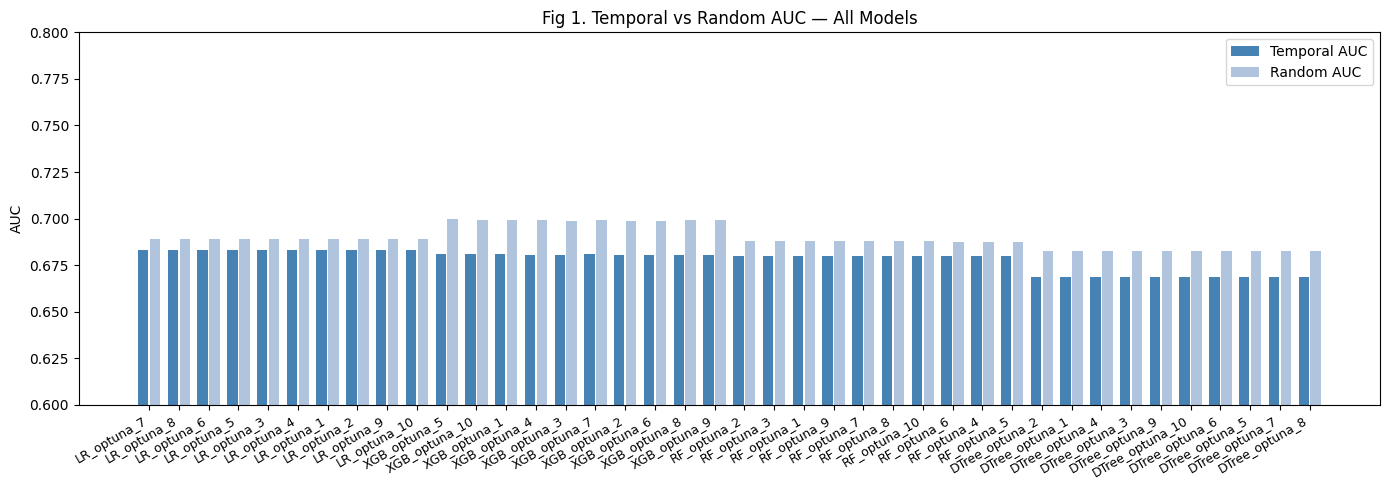

In [55]:
# ═══════════════════════════════════════════════════════════════════════
# Figure 1: Temporal AUC comparison (all model)
# ═══════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(14, 5))

model_names = df_results['Model'].tolist()
t_aucs = df_results['Temporal AUC'].tolist()
r_aucs = df_results['Random AUC'].tolist()

x = np.arange(len(model_names))
bars1 = ax.bar(x - 0.2, t_aucs, width=0.35, label='Temporal AUC', color='steelblue')
bars2 = ax.bar(x + 0.2, r_aucs, width=0.35, label='Random AUC',   color='lightsteelblue')

ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=30, ha='right', fontsize=9)
ax.set_ylim(0.60, 0.80)
ax.set_ylabel('AUC')
ax.set_title('Fig 1. Temporal vs Random AUC — All Models')
ax.legend()
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.3f'))
plt.tight_layout()
plt.savefig('/content/fig1_auc_comparison.png', dpi=150)
plt.show()

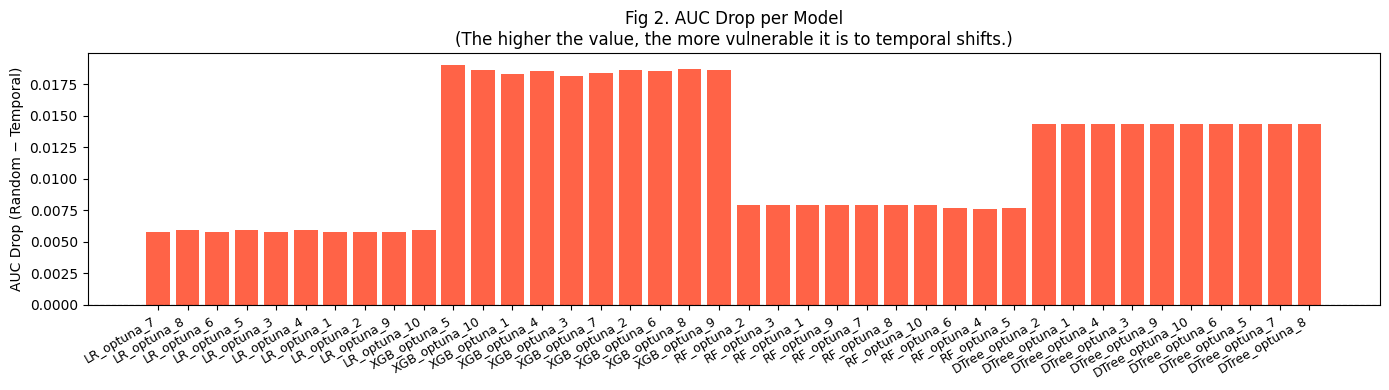

In [56]:
# ═══════════════════════════════════════════════════════════════════════
# Figure 2: AUC Drop (Temporal how much decrease)
# ═══════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(14, 4))

drops = df_results['AUC Drop'].tolist()
colors = ['tomato' if d > 0 else 'seagreen' for d in drops]

ax.bar(model_names, drops, color=colors)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xticks(np.arange(len(model_names)))
ax.set_xticklabels(model_names, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('AUC Drop (Random − Temporal)')
ax.set_title('Fig 2. AUC Drop per Model\n(The higher the value, the more vulnerable it is to temporal shifts.)')
plt.tight_layout()
plt.savefig('/content/fig2_auc_drop.png', dpi=150)
plt.show()

In [47]:
# Deprecated duplicate Figure 3 block removed.
# Use the current yearly-AUC Figure 3 cell below, which draws from `all_results` and `REPRESENTATIVE_MODELS`.


In [48]:
# Deprecated duplicate Figure 4 block removed.
# Use the current validation-ranking Figure 4 cell below, which saves `fig4_validation_auc.png`.


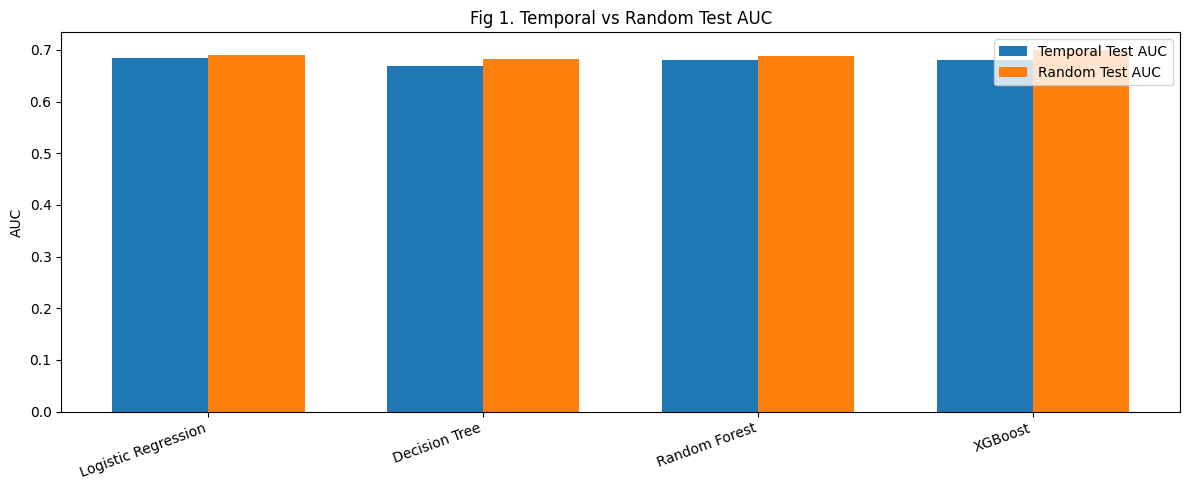

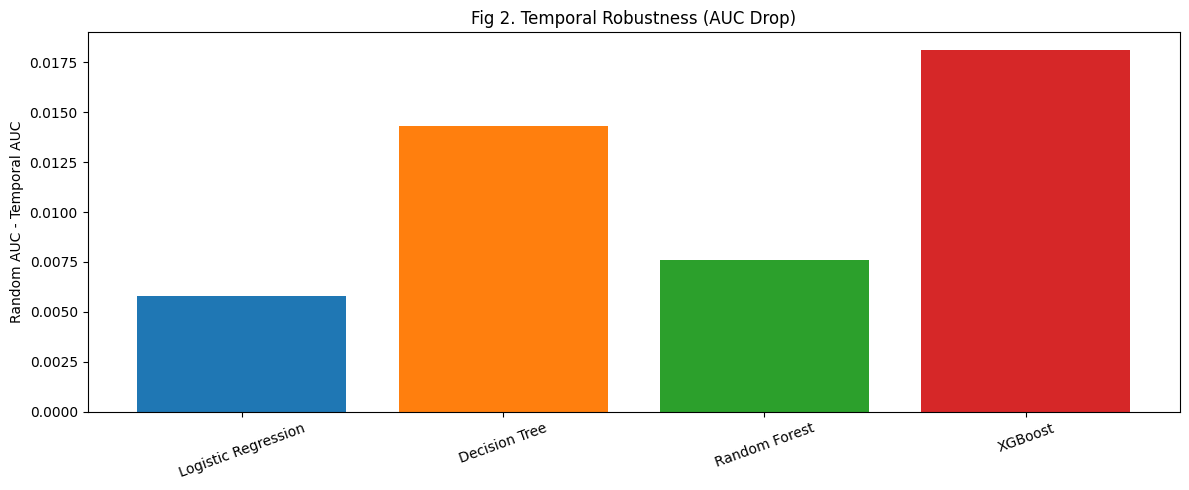

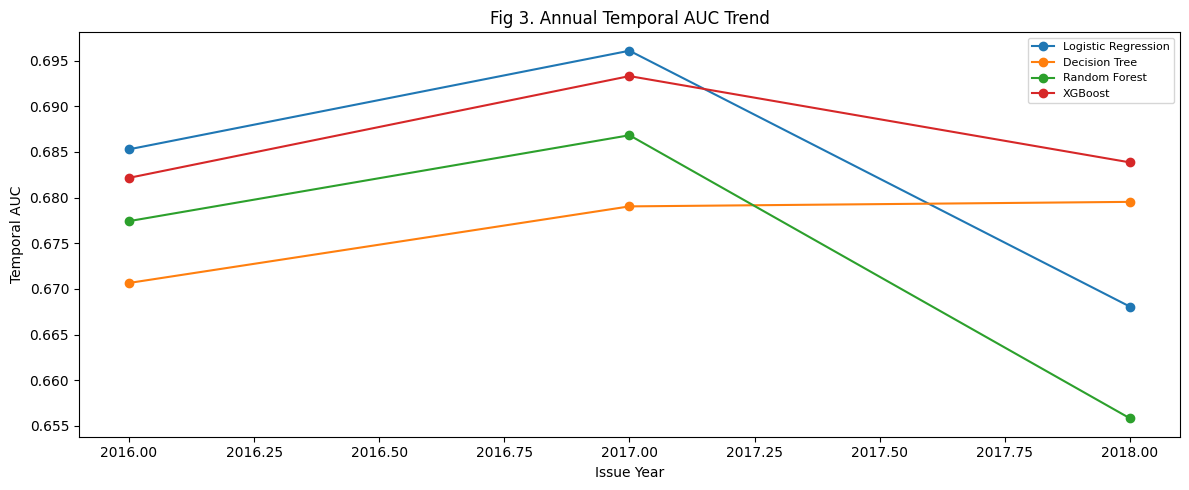

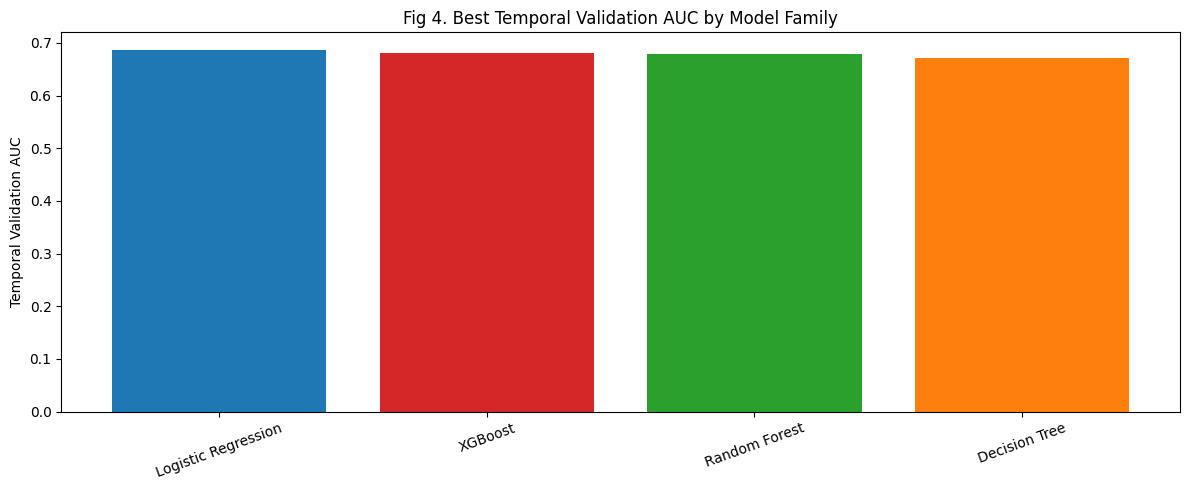

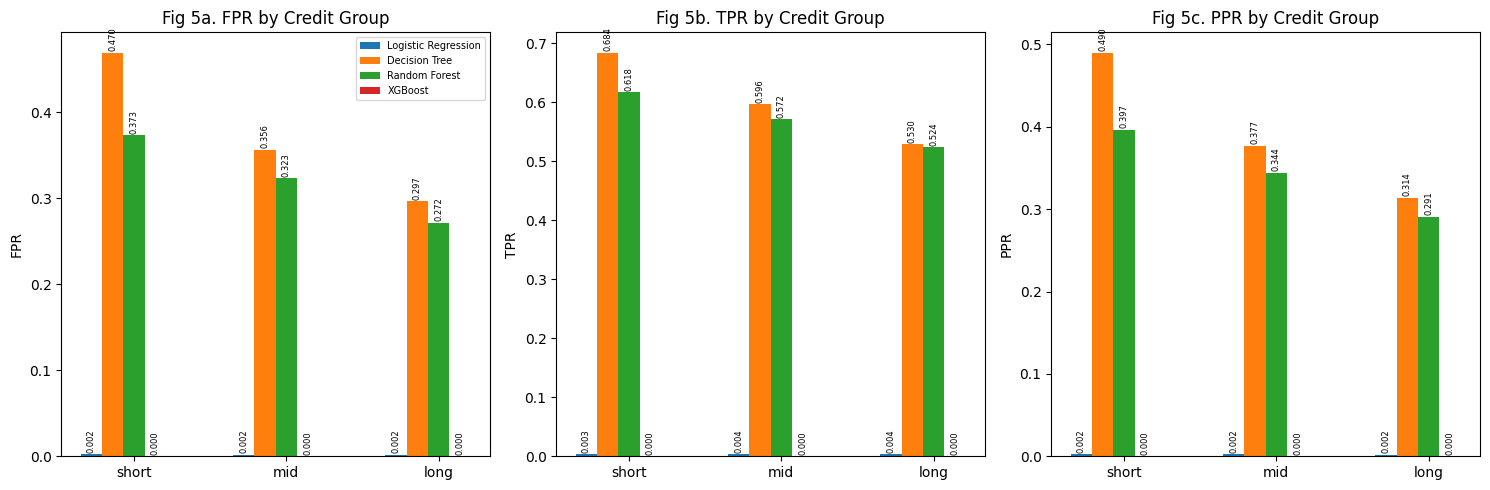

In [57]:
# ════════════════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import numpy as np

# Figure 1: Temporal vs random AUC for one representative per model family
family_order = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost']
family_display = {
    'Logistic Regression': 'Logistic Regression',
    'Decision Tree': 'Decision Tree',
    'Random Forest': 'Random Forest',
    'XGBoost': 'XGBoost',
}
family_colors = {
    'Logistic Regression': '#1f77b4',
    'Decision Tree': '#ff7f0e',
    'Random Forest': '#2ca02c',
    'XGBoost': '#d62728',
}

plot_df = df_representatives.copy()
plot_df['Family'] = plot_df['Model'].apply(infer_family)
plot_df['Family'] = pd.Categorical(plot_df['Family'], categories=family_order, ordered=True)
plot_df = plot_df.sort_values('Family').copy()
plot_df['Display'] = plot_df['Family'].map(family_display)

FAIR_MODELS_PLOT = plot_df['Model'].tolist()
FAIR_FAMILIES_PLOT = plot_df['Family'].astype(str).tolist()
FAIR_LABELS_PLOT = plot_df['Display'].tolist()
colors_fair = [family_colors.get(f, '#9467bd') for f in FAIR_FAMILIES_PLOT]

x = np.arange(len(plot_df))
width = 0.35
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width/2, plot_df['Temporal AUC'], width=width, label='Temporal Test AUC', color='#1f77b4')
ax.bar(x + width/2, plot_df['Random AUC'], width=width, label='Random Test AUC', color='#ff7f0e')
ax.set_xticks(x)
ax.set_xticklabels(plot_df['Display'], rotation=20, ha='right')
ax.set_ylabel('AUC')
ax.set_title('Fig 1. Temporal vs Random Test AUC')
ax.legend()
plt.tight_layout()
plt.savefig('/content/fig1_auc_comparison.png', dpi=150)
plt.show()

# Figure 2: AUC drop for one representative per model family
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(plot_df['Display'], plot_df['AUC Drop'], color=[family_colors.get(f, '#2ca02c') for f in plot_df['Family'].astype(str)])
ax.set_ylabel('Random AUC - Temporal AUC')
ax.set_title('Fig 2. Temporal Robustness (AUC Drop)')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig('/content/fig2_auc_drop.png', dpi=150)
plt.show()

# Figure 3: Annual temporal AUC trend
fig, ax = plt.subplots(figsize=(12, 5))
for mname, family_label in zip(FAIR_MODELS_PLOT, FAIR_LABELS_PLOT):
    year_map = all_results[mname]['yearly']
    years = sorted(year_map.keys())
    vals = [year_map[y] for y in years]
    ax.plot(years, vals, marker='o', label=family_label)
ax.set_xlabel('Issue Year')
ax.set_ylabel('Temporal AUC')
ax.set_title('Fig 3. Annual Temporal AUC Trend')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('/content/fig3_auc_over_time.png', dpi=150)
plt.show()

# Figure 4: Best validation AUC by model family
fig, ax = plt.subplots(figsize=(12, 5))
fig4_df = df_representatives.sort_values('Temporal Val AUC', ascending=False).copy()
fig4_df['Family'] = fig4_df['Model'].apply(infer_family)
fig4_df['Display'] = fig4_df['Family'].map(family_display)
ax.bar(fig4_df['Display'], fig4_df['Temporal Val AUC'], color=[family_colors.get(f, '#9467bd') for f in fig4_df['Family']])
ax.set_ylabel('Temporal Validation AUC')
ax.set_title('Fig 4. Best Temporal Validation AUC by Model Family')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig('/content/fig4_validation_auc.png', dpi=150)
plt.show()

# Figure 5: Fairness by credit-history group at threshold 0.5
FAIR_MODELS_PLOT = REPRESENTATIVE_MODELS.copy()
family_map = dict(zip(representative_lookup['Model'], representative_lookup['Family']))
FAIR_LABELS_PLOT = [family_display.get(family_map.get(m, ''), m) for m in FAIR_MODELS_PLOT]
colors_fair = [family_colors.get(family_map.get(m, ''), '#9467bd') for m in FAIR_MODELS_PLOT]

credit_groups = ['short', 'mid', 'long']
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = ['FPR', 'TPR', 'PPR']
for ax_i, metric in enumerate(metrics):
    x = np.arange(len(credit_groups))
    width = 0.14
    for j, (mname, family_label, col) in enumerate(zip(FAIR_MODELS_PLOT, FAIR_LABELS_PLOT, colors_fair)):
        df_f = fairness_results.get(mname, {}).get('credit', pd.DataFrame(columns=['group'] + metrics))
        vals = df_f.set_index('group').reindex(credit_groups)[metric].fillna(0).tolist()
        offset = (j - len(FAIR_MODELS_PLOT) / 2) * width
        bars = axes[ax_i].bar(x + offset, vals, width=width, label=family_label, color=col)
        for bar, val in zip(bars, vals):
            axes[ax_i].text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.002,
                f'{val:.3f}',
                ha='center',
                va='bottom',
                fontsize=6,
                rotation=90
            )
    axes[ax_i].set_xticks(x)
    axes[ax_i].set_xticklabels(credit_groups)
    axes[ax_i].set_title(f'Fig 5{chr(97+ax_i)}. {metric} by Credit Group')
    axes[ax_i].set_ylabel(metric)
    if ax_i == 0:
        axes[ax_i].legend(fontsize=7)
plt.tight_layout()
plt.savefig('/content/fig5_fairness_credit.png', dpi=150)
plt.show()


In [58]:
print(REPRESENTATIVE_MODELS)
print(representative_lookup)

['LR_optuna_1', 'DTree_optuna_2', 'RF_optuna_4', 'XGB_optuna_3']
                Family           Model
0  Logistic Regression     LR_optuna_1
1        Decision Tree  DTree_optuna_2
2        Random Forest     RF_optuna_4
3              XGBoost    XGB_optuna_3


In [59]:
print(study_dt.best_params)
# 또는
for i, t in enumerate(top_trials_dt):
    if i == 1:  # optuna_2는 index 1
        print(t.params)

{'max_depth': 3, 'min_samples_leaf': 10, 'min_samples_split': 16, 'criterion': 'gini', 'class_weight': 'balanced'}
{'max_depth': 3, 'min_samples_leaf': 46, 'min_samples_split': 14, 'criterion': 'gini', 'class_weight': 'balanced'}


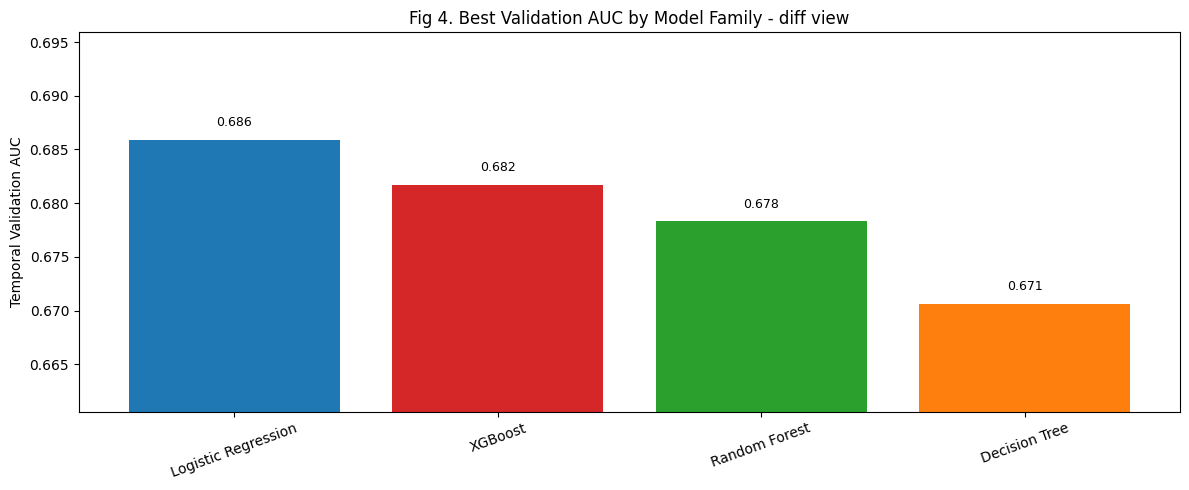

In [50]:
# Figure 4 alternate view: sorted high-to-low with a careful zoomed y-axis
fig4_alt_df = df_representatives.copy()
fig4_alt_df['Family'] = fig4_alt_df['Model'].apply(infer_family)
fig4_alt_df['Display'] = fig4_alt_df['Family'].map(family_display)
fig4_alt_df = fig4_alt_df.sort_values('Temporal Val AUC', ascending=False).copy()

ymin = max(0.0, fig4_alt_df['Temporal Val AUC'].min() - 0.01)
ymax = min(1.0, fig4_alt_df['Temporal Val AUC'].max() + 0.01)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(
    fig4_alt_df['Display'],
    fig4_alt_df['Temporal Val AUC'],
    color=[family_colors.get(f, '#9467bd') for f in fig4_alt_df['Family']]
)
ax.set_ylabel('Temporal Validation AUC')
ax.set_title('Fig 4. Best Validation AUC by Model Family - diff view')
ax.set_ylim(ymin, ymax)
ax.tick_params(axis='x', rotation=20)

for bar, val in zip(bars, fig4_alt_df['Temporal Val AUC']):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.001, f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


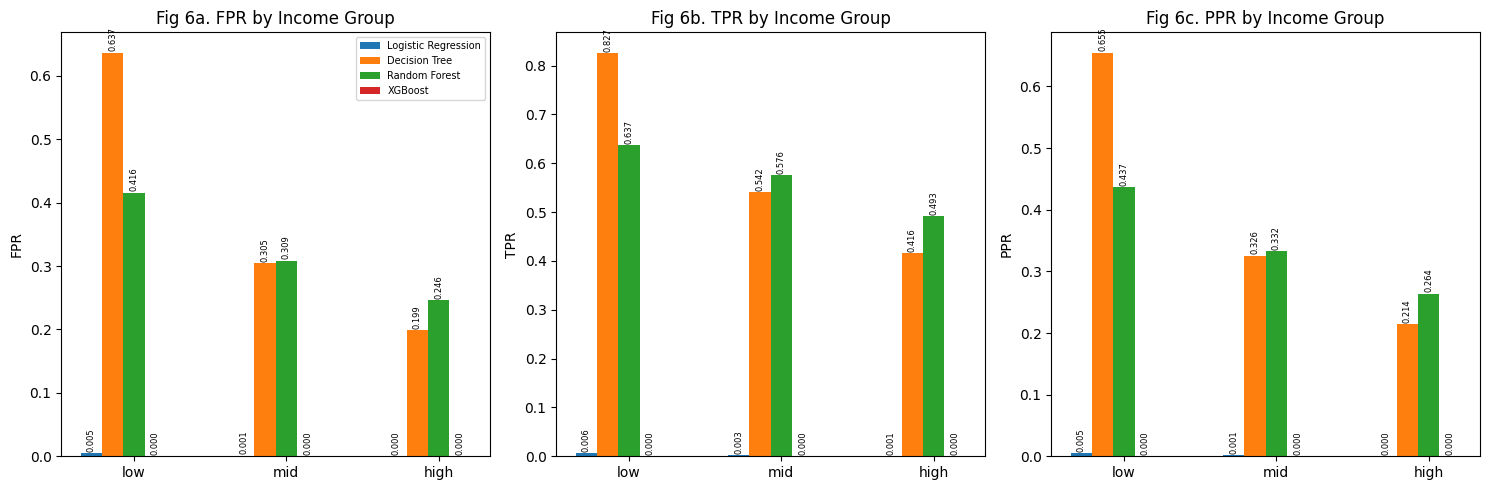

In [51]:
# Figure 6: Fairness by income group at threshold 0.5
FAIR_MODELS_PLOT = REPRESENTATIVE_MODELS.copy()
family_map = dict(zip(representative_lookup['Model'], representative_lookup['Family']))
FAIR_LABELS_PLOT = [family_display.get(family_map.get(m, ''), m) for m in FAIR_MODELS_PLOT]
colors_fair = [family_colors.get(family_map.get(m, ''), '#9467bd') for m in FAIR_MODELS_PLOT]

income_groups = ['low', 'mid', 'high']
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax_i, metric in enumerate(metrics):
    x = np.arange(len(income_groups))
    width = 0.14
    for j, (mname, family_label, col) in enumerate(zip(FAIR_MODELS_PLOT, FAIR_LABELS_PLOT, colors_fair)):
        df_f = fairness_results.get(mname, {}).get('income', pd.DataFrame(columns=['group'] + metrics))
        vals = df_f.set_index('group').reindex(income_groups)[metric].fillna(0).tolist()
        offset = (j - len(FAIR_MODELS_PLOT) / 2) * width
        bars = axes[ax_i].bar(x + offset, vals, width=width, label=family_label, color=col)
        for bar, val in zip(bars, vals):
            axes[ax_i].text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.002,
                f'{val:.3f}',
                ha='center',
                va='bottom',
                fontsize=6,
                rotation=90
            )
    axes[ax_i].set_xticks(x)
    axes[ax_i].set_xticklabels(income_groups)
    axes[ax_i].set_title(f'Fig 6{chr(97+ax_i)}. {metric} by Income Group')
    axes[ax_i].set_ylabel(metric)
    if ax_i == 0:
        axes[ax_i].legend(fontsize=7)
plt.tight_layout()
plt.savefig('/content/fig6_fairness_income.png', dpi=150)
plt.show()


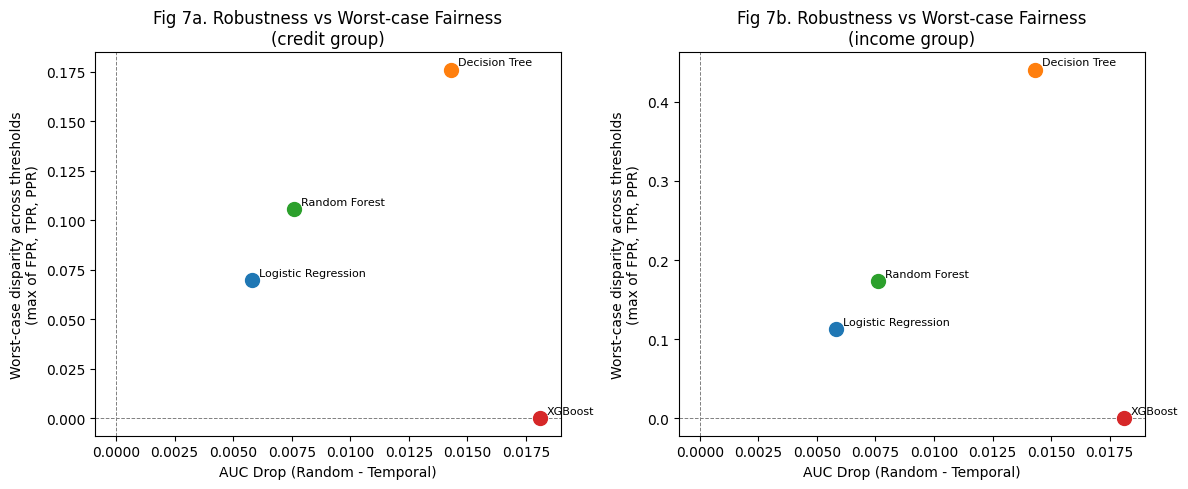

In [52]:
# Figure 7: Robustness vs worst-case fairness disparity
FAIR_MODELS_PLOT = REPRESENTATIVE_MODELS.copy()
family_map = dict(zip(representative_lookup['Model'], representative_lookup['Family']))
FAIR_LABELS_PLOT = [family_display.get(family_map.get(m, ''), m) for m in FAIR_MODELS_PLOT]
colors_fair = [family_colors.get(family_map.get(m, ''), '#9467bd') for m in FAIR_MODELS_PLOT]

tradeoff_df = df_fairness_summary[df_fairness_summary['Model'].isin(FAIR_MODELS_PLOT)].copy()
tradeoff_df['Worst Credit Overall_disp'] = tradeoff_df[['Worst Credit FPR_disp', 'Worst Credit TPR_disp', 'Worst Credit PPR_disp']].max(axis=1)
tradeoff_df['Worst Income Overall_disp'] = tradeoff_df[['Worst Income FPR_disp', 'Worst Income TPR_disp', 'Worst Income PPR_disp']].max(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax_i, (y_col, title_suffix) in enumerate([
    ('Worst Credit Overall_disp', 'credit group'),
    ('Worst Income Overall_disp', 'income group'),
]):
    for mname, family_label, col in zip(FAIR_MODELS_PLOT, FAIR_LABELS_PLOT, colors_fair):
        row = tradeoff_df[tradeoff_df['Model'] == mname].iloc[0]
        x_val = row['AUC Drop']
        y_val = row[y_col]
        axes[ax_i].scatter(x_val, y_val, color=col, s=100, label=family_label, zorder=3)
        axes[ax_i].annotate(family_label, (x_val, y_val), textcoords='offset points', xytext=(5, 3), fontsize=8)
    axes[ax_i].set_xlabel('AUC Drop (Random - Temporal)')
    axes[ax_i].set_ylabel('Worst-case disparity across thresholds\n(max of FPR, TPR, PPR)')
    axes[ax_i].set_title(f'Fig 7{chr(97+ax_i)}. Robustness vs Worst-case Fairness\n({title_suffix})')
    axes[ax_i].axhline(0, color='gray', linestyle='--', linewidth=0.7)
    axes[ax_i].axvline(0, color='gray', linestyle='--', linewidth=0.7)
plt.tight_layout()
plt.savefig('/content/fig7_tradeoff.png', dpi=150)
plt.show()


## 8. Output Final Summary Table (For Presentation)

In [53]:
# Representative summary table aligned with the current pipeline
df_summary = df_ranked[df_ranked['Model'].isin(REPRESENTATIVE_MODELS)].copy()
df_summary['Model'] = pd.Categorical(df_summary['Model'], categories=REPRESENTATIVE_MODELS, ordered=True)
df_summary = df_summary.sort_values('Model')
print('=== Summary Table (Representative Models) ===')
print(df_summary.to_string(index=False))

df_summary.to_csv('/content/prefinal_summary.csv', index=False)
df_results.to_csv('/content/prefinal_full_results.csv', index=False)
print('\nCSV saved: prefinal_summary.csv, prefinal_full_results.csv')

=== Summary Table (Representative Models) ===
         Model  Temporal Val AUC  Temporal AUC  Accuracy  AUC Drop  Worst Credit FPR_disp  Worst Income FPR_disp  Worst Credit TPR_disp  Worst Income TPR_disp  Worst Credit PPR_disp  Worst Income PPR_disp  _fair_norm  composite_score
   LR_optuna_1            0.6859        0.6833    0.9142    0.0058                 0.0544                 0.1095                 0.0699                 0.1021                 0.0593                 0.1130    0.309507         0.124370
DTree_optuna_2            0.6706        0.6685    0.6336    0.0143                 0.1732                 0.4381                 0.1549                 0.4106                 0.1761                 0.4408    1.000000         0.875379
   RF_optuna_4            0.6783        0.6799    0.6740    0.0076                 0.1016                 0.1695                 0.0942                 0.1443                 0.1058                 0.1731    0.487761         0.403025
  XGB_optuna_3    

## 9. Save Files (Google Drive)
Save Resulting PNG + CSV to Drive

In [54]:
import shutil, os

SAVE_DIR = '/content/drive/MyDrive/Colab Notebooks/CSCI567'
os.makedirs(SAVE_DIR, exist_ok=True)

files_to_save = [
    '/content/fig1_auc_comparison.png',
    '/content/fig2_auc_drop.png',
    '/content/fig3_auc_over_time.png',
    '/content/fig4_validation_auc.png',
    '/content/fig5_fairness_credit.png',
    '/content/fig6_fairness_income.png',
    '/content/fig7_tradeoff.png',
    '/content/prefinal_summary.csv',
    '/content/prefinal_full_results.csv',
]

for f in files_to_save:
    if os.path.exists(f):
        shutil.copy(f, SAVE_DIR)
        print(f'Saved: {os.path.basename(f)}')
    else:
        print(f'NOT FOUND: {f}')

Saved: fig1_auc_comparison.png
Saved: fig2_auc_drop.png
Saved: fig3_auc_over_time.png
Saved: fig4_validation_auc.png
Saved: fig5_fairness_credit.png
Saved: fig6_fairness_income.png
Saved: fig7_tradeoff.png
Saved: prefinal_summary.csv
Saved: prefinal_full_results.csv
